# **Installing Dependencies**

In [ ]:
!pip install torch_geometric
!pip install rdkit
!pip install scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 21.3 MB/s eta 0:00:00


# Using the 12 groups of the 138 smells

## **Dataset Preprocessing**

## Importing the dataset

In [ ]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/fperone/Projet_IA-Generative-pour-la-decouverte-moleculaire/refs/heads/main/Multi-Labelled_Smiles_Odors_dataset.csv')

df.head()

,nonStereoSMILES,descriptors,alcoholic,aldehydic,alliaceous,almond,amber,animal,anisic,apple,...,tropical,vanilla,vegetable,vetiver,violet,warm,waxy,weedy,winey,woody
0,CC(O)CN,fishy,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,CCC(=O)C(=O)O,fatty;lactonic;sweet;caramellic;creamy,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,O=C(O)CCc1ccccc1,rose;floral;fatty;sweet;musk;cinnamon;balsamic,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,OCc1ccc(O)cc1,medicinal;phenolic;fruity;nutty;bitter;sweet;a...,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,O=Cc1ccc(O)cc1,phenolic;woody;nutty;vanilla;hay;metallic;swee...,0,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1


In [ ]:
df_new_dataset = pd.read_csv('7Q27.normalized.signatures_with_smiles.csv')
df_new_dataset = df_new_dataset.head(-3)['SMILES']
new_molecules = df_new_dataset.unique()
new_molecules

array(['CC(C)/C=C/C=C(\\C)/C=C', 'CC1=CCC2C(C1)C2(C)C',
       'CC(=CCCC(C)(C=C)O)C', 'CC1=C[C@H]2C[C@@H](C1)C2(C)C',
       'CC1=CC[C@H](CC1)C(=C)C', 'CC1=CC[C@@H](CC1)C(=C)C'], dtype=object)

In [ ]:
df.shape

(4983, 140)

## Checking for NaNs in the dataset

In [ ]:
df.isna().sum()

,0
nonStereoSMILES,0
descriptors,0
alcoholic,0
aldehydic,0
alliaceous,0
...,...
warm,0
waxy,0
weedy,0
winey,0


Substituting NaNs for Zeros

In [ ]:
df.fillna(0, inplace=True)
df.isna().sum()

,0
nonStereoSMILES,0
descriptors,0
alcoholic,0
aldehydic,0
alliaceous,0
...,...
warm,0
waxy,0
weedy,0
winey,0


Defining the 12 groups of smells and grouping the labels accordingly

In [ ]:
META_CATEGORIES = {
    "floral": ["floral", "rose", "jasmin", "lily", "muguet", "violet", "hyacinth",
               "geranium", "lavender", "orangeflower", "chamomile", "hawthorn"],
    "fruity": ["fruity", "apple", "apricot", "banana", "berry", "cherry", "grape",
               "grapefruit", "lemon", "melon", "orange", "peach", "pear", "pineapple",
               "plum", "raspberry", "strawberry", "tropical", "black currant", "fruit skin"],
    "sweet": ["sweet", "vanilla", "caramellic", "honey", "chocolate", "cocoa",
              "coconut", "creamy", "buttery", "milky", "dairy"],
    "woody": ["woody", "cedar", "sandalwood", "pine", "vetiver", "terpenic",
              "balsamic", "cortex"],
    "green": ["green", "grassy", "herbal", "leafy", "hay", "tea", "fresh",
              "cucumber", "vegetable", "weedy"],
    "spicy": ["spicy", "cinnamon", "clove", "warm", "pungent", "sharp",
              "cooling", "mint", "camphoreous"],
    "animal_musk": ["animal", "musk", "leathery", "fishy", "sweaty", "meaty",
                    "beefy", "musty"],
    "earthy": ["earthy", "mushroom", "nutty", "hazelnut", "roasted", "coffee",
               "tobacco", "smoky", "popcorn"],
    "citrus": ["citrus", "bergamot", "ozone", "clean", "soapy"],
    "chemical": ["solvent", "ethereal", "metallic", "medicinal", "phenolic",
                 "sulfurous", "gassy", "burnt", "oily"],
    "gourmand": ["almond", "malty", "rummy", "brandy", "cognac", "winey",
                 "cooked", "potato", "savory", "celery", "tomato", "radish",
                 "onion", "garlic", "cabbage", "cheesy"],
    "powdery_amber": ["amber", "powdery", "anisic", "coumarinic", "orris",
                      "waxy", "aldehydic", "ketonic", "lactonic"],
}

In [ ]:
# Create a new DataFrame to store the grouped categories
grouped_categories_df = pd.DataFrame()

# Get the existing smell columns from df (columns from index 2 onwards)
smell_columns_in_df = df.columns[2:]

# Iterate through each meta-category defined in META_CATEGORIES
for category_name, smells_in_category in META_CATEGORIES.items():
    # Filter the smells for the current category to only include those present in the original df columns
    relevant_smell_columns = [s for s in smells_in_category if s in smell_columns_in_df]

    if relevant_smell_columns:
        # If there are relevant smell columns, create the new category column.
        # The value will be 1 if any of the relevant original smell columns is 1, else 0.
        grouped_categories_df[category_name] = df[relevant_smell_columns].max(axis=1)
    else:
        # If no relevant smell columns are found for a category, fill the new column with zeros.
        grouped_categories_df[category_name] = 0

# Keep the 'nonStereoSMILES' and 'descriptors' columns from the original df
df_processed = df[['nonStereoSMILES', 'descriptors']].copy()

# Concatenate the preserved original columns with the new grouped category columns
df = pd.concat([df_processed, grouped_categories_df], axis=1)

# Display the head of the modified DataFrame to verify the changes
df.head()

,nonStereoSMILES,descriptors,floral,fruity,sweet,woody,green,spicy,animal_musk,earthy,citrus,chemical,gourmand,powdery_amber
0,CC(O)CN,fishy,0,0,0,0,0,0,1,0,0,0,0,0
1,CCC(=O)C(=O)O,fatty;lactonic;sweet;caramellic;creamy,0,0,1,0,0,0,0,0,0,0,0,1
2,O=C(O)CCc1ccccc1,rose;floral;fatty;sweet;musk;cinnamon;balsamic,1,0,1,1,0,1,1,0,0,0,0,0
3,OCc1ccc(O)cc1,medicinal;phenolic;fruity;nutty;bitter;sweet;a...,0,1,1,0,0,0,0,1,0,1,1,0
4,O=Cc1ccc(O)cc1,phenolic;woody;nutty;vanilla;hay;metallic;swee...,0,0,1,1,1,0,0,1,0,1,1,0


In [ ]:
df.shape

(4983, 14)

## Converting the SMILES representation to a graph one

### Converting the SMILES to graphs with `from_smiles`

In [ ]:
import torch
from torch_geometric.utils import from_smiles
from torch_geometric.utils import to_networkx

df_graph = []
labels = []
G = []

for i in range(len(df)):
  smiles = df['nonStereoSMILES'][i]
  data = from_smiles(smiles, with_hydrogen=0)
  data.x = data.x.float()
  data.y = torch.tensor(df.iloc[i, 2:], dtype=torch.float)
  df_graph.append(data)
  G.append(to_networkx(data, to_undirected=True))
  labels.append(df.iloc[i, 2:])

/tmp/ipykernel_2687/3099259129.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data.y = torch.tensor(df.iloc[i, 2:], dtype=torch.float)


## Creating the train and test loaders

In [ ]:
# !pip install scikit-multilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 4.8 MB/s eta 0:00:00


### Second-order iterative stratification

In [ ]:
# import numpy as np
# import pandas as pd
# from skmultilearn.model_selection import IterativeStratification
# from torch_geometric.loader import DataLoader
# import torch

# def create_stratified_splits(df, label_columns, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1):
#     X = np.arange(len(df)).reshape(-1, 1)
#     y = label_columns

#     holdout_ratio = val_ratio + test_ratio

#     stratifier_1 = IterativeStratification(
#         n_splits=2,
#         order=2,
#         sample_distribution_per_fold=[holdout_ratio, train_ratio]
#     )

#     train_idx, holdout_idx = next(stratifier_1.split(X, y))

#     print(f"   -> Step 1 Complete: {len(train_idx)} Train samples, {len(holdout_idx)} Holdout samples.")

#     relative_test_ratio = test_ratio / holdout_ratio
#     relative_val_ratio = 1.0 - relative_test_ratio

#     stratifier_2 = IterativeStratification(
#         n_splits=2,
#         order=2,
#         sample_distribution_per_fold=[relative_test_ratio, relative_val_ratio]
#     )

#     X_holdout = X[holdout_idx]
#     y_holdout = y[holdout_idx]

#     val_idx_relative, test_idx_relative = next(stratifier_2.split(X_holdout, y_holdout))

#     val_idx = holdout_idx[val_idx_relative]
#     test_idx = holdout_idx[test_idx_relative]

#     print(f"   -> Step 2 Complete: {len(val_idx)} Val samples, {len(test_idx)} Test samples.")

#     df_train = df.iloc[train_idx].copy()
#     df_val = df.iloc[val_idx].copy()
#     df_test = df.iloc[test_idx].copy()

#     return df_train, df_val, df_test


# train_data, val_data, test_data = create_stratified_splits(
#     df=df,
#     label_columns=df.iloc[:, 2:].values,
#     train_ratio=0.8,
#     val_ratio=0.1,
#     test_ratio=0.1
# )

# df_graph_train = []
# df_graph_val = []
# df_graph_test = []
# labels_train = []
# labels_val = []
# labels_test = []
# G = []

# for i in range(len(train_data)):
#   smiles = train_data['nonStereoSMILES'].iloc[i]
#   data = from_smiles(smiles, with_hydrogen=0)
#   data.x = data.x.float()
#   data.y = torch.tensor(train_data.iloc[i, 2:], dtype=torch.float)
#   df_graph_train.append(data)
#   G.append(to_networkx(data, to_undirected=True))
#   labels_train.append(train_data.iloc[i, 2:])

# for i in range(len(val_data)):
#   smiles = val_data['nonStereoSMILES'].iloc[i]
#   data = from_smiles(smiles, with_hydrogen=0)
#   data.x = data.x.float()
#   data.y = torch.tensor(val_data.iloc[i, 2:], dtype=torch.float)
#   df_graph_val.append(data)
#   G.append(to_networkx(data, to_undirected=True))
#   labels_val.append(val_data.iloc[i, 2:])

# for i in range(len(test_data)):
#   smiles = test_data['nonStereoSMILES'].iloc[i]
#   data = from_smiles(smiles, with_hydrogen=0)
#   data.x = data.x.float()
#   data.y = torch.tensor(test_data.iloc[i, 2:], dtype=torch.float)
#   df_graph_test.append(data)
#   G.append(to_networkx(data, to_undirected=True))
#   labels_test.append(test_data.iloc[i, 2:])

# train_data = df_graph_train
# val_data = df_graph_val
# test_data = df_graph_test

# train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
# val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False) # no shuffle needed for eval
# test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False)

   -> Step 1 Complete: 3964 Train samples, 1019 Holdout samples.
   -> Step 2 Complete: 512 Val samples, 507 Test samples.


/tmp/ipykernel_16275/439607195.py:69: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data.y = torch.tensor(train_data.iloc[i, 2:], dtype=torch.float)
/tmp/ipykernel_16275/439607195.py:69: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data.y = torch.tensor(train_data.iloc[i, 2:], dtype=torch.float)
/tmp/ipykernel_16275/439607195.py:69: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data.y = torch.tensor(train_data.iloc[i, 2:], dtype=to

### Splits (not using second-order iterative stratification)

In [ ]:
from torch_geometric.loader import DataLoader
import torch

# splitting the dataset into train and test sets
total_size = len(df_graph)
train_size = int(total_size * 0.8)  # 80% for training
val_size   = int(total_size * 0.1)  # 10% for validation
test_size  = total_size - train_size - val_size # 10% for test

# perform the split
train_data = df_graph[:train_size]
val_data   = df_graph[train_size : train_size + val_size]
test_data  = df_graph[train_size + val_size :]

# create loaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False) # no shuffle needed for eval
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False)

len(train_data), len(val_data), len(test_data)

(3986, 498, 499)

## **GNN Implementation**

## Model Creation

### GCN Model

#### Global mean pool

##### 2 GCN Layers

In [ ]:
# import torch.nn.functional as F
# from torch_geometric.nn import GCNConv, global_mean_pool

# class SmellPredictor(torch.nn.Module):
#     def __init__(self, num_node_features, num_classes=138):
#         super(SmellPredictor, self).__init__()

#         self.conv1 = GCNConv(num_node_features, 64)
#         self.conv2 = GCNConv(64, 128)
#         # self.conv3 = GCNConv(128, 128)

#         self.lin = torch.nn.Linear(128, num_classes)

#     def forward(self, data):
#         x, edge_index, batch = data.x, data.edge_index, data.batch

#         x = self.conv1(x, edge_index)
#         x = F.relu(x)
#         x = self.conv2(x, edge_index)
#         # x = F.relu(x)
#         # x = self.conv3(x, edge_index)

#         x = global_mean_pool(x, batch)

#         x = self.lin(x)

#         return x

##### 3 GCN Layers

In [ ]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class SmellPredictor(torch.nn.Module):
    def __init__(self, num_node_features, num_classes=138):
        super(SmellPredictor, self).__init__()

        self.conv1 = GCNConv(num_node_features, 64)
        self.conv2 = GCNConv(64, 128)
        self.conv3 = GCNConv(128, 128)

        self.lin = torch.nn.Linear(128, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)

        x = global_mean_pool(x, batch)

        x = self.lin(x)

        return x

##### 4 GCN Layers

In [ ]:
# import torch.nn.functional as F
# from torch_geometric.nn import GCNConv, global_mean_pool

# class SmellPredictor(torch.nn.Module):
#     def __init__(self, num_node_features, num_classes=138):
#         super(SmellPredictor, self).__init__()

#         self.conv1 = GCNConv(num_node_features, 64)
#         self.conv2 = GCNConv(64, 128)
#         self.conv3 = GCNConv(128, 256) # changed this layer to fit the fourth layer
#         self.conv4 = GCNConv(256, 128) # new layer

#         self.lin = torch.nn.Linear(128, num_classes)

#     def forward(self, data):
#         x, edge_index, batch = data.x, data.edge_index, data.batch

#         x = self.conv1(x, edge_index)
#         x = F.relu(x)
#         x = self.conv2(x, edge_index)
#         x = F.relu(x)
#         x = self.conv3(x, edge_index)
#         x = F.relu(x)
#         x = self.conv4(x, edge_index)

#         x = global_mean_pool(x, batch)

#         x = self.lin(x)

#         return x

#### Global max pool

##### 2 GCN Layers

In [ ]:
# import torch.nn.functional as F
# from torch_geometric.nn import GCNConv, global_max_pool

# class SmellPredictor(torch.nn.Module):
#     def __init__(self, num_node_features, num_classes=138):
#         super(SmellPredictor, self).__init__()

#         self.conv1 = GCNConv(num_node_features, 64)
#         self.conv2 = GCNConv(64, 128)
#         # self.conv3 = GCNConv(128, 128)

#         self.lin = torch.nn.Linear(128, num_classes)

#     def forward(self, data):
#         x, edge_index, batch = data.x, data.edge_index, data.batch

#         x = self.conv1(x, edge_index)
#         x = F.relu(x)
#         x = self.conv2(x, edge_index)
#         # x = F.relu(x)
#         # x = self.conv3(x, edge_index)

#         x = global_max_pool(x, batch)

#         x = self.lin(x)

#         return x

##### 3 GCN Layers

In [ ]:
# import torch.nn.functional as F
# from torch_geometric.nn import GCNConv, global_max_pool

# class SmellPredictor(torch.nn.Module):
#     def __init__(self, num_node_features, num_classes=138):
#         super(SmellPredictor, self).__init__()

#         self.conv1 = GCNConv(num_node_features, 64)
#         self.conv2 = GCNConv(64, 128)
#         self.conv3 = GCNConv(128, 128)

#         self.lin = torch.nn.Linear(128, num_classes)

#     def forward(self, data):
#         x, edge_index, batch = data.x, data.edge_index, data.batch

#         x = self.conv1(x, edge_index)
#         x = F.relu(x)
#         x = self.conv2(x, edge_index)
#         x = F.relu(x)
#         x = self.conv3(x, edge_index)

#         x = global_max_pool(x, batch)

#         x = self.lin(x)

#         return x

##### 4 GCN Layers

In [ ]:
# import torch.nn.functional as F
# from torch_geometric.nn import GCNConv, global_max_pool

# class SmellPredictor(torch.nn.Module):
#     def __init__(self, num_node_features, num_classes=138):
#         super(SmellPredictor, self).__init__()

#         self.conv1 = GCNConv(num_node_features, 64)
#         self.conv2 = GCNConv(64, 128)
#         self.conv3 = GCNConv(128, 256) # changed this layer to fit the fourth layer
#         self.conv4 = GCNConv(256, 128) # new layer

#         self.lin = torch.nn.Linear(128, num_classes)

#     def forward(self, data):
#         x, edge_index, batch = data.x, data.edge_index, data.batch

#         x = self.conv1(x, edge_index)
#         x = F.relu(x)
#         x = self.conv2(x, edge_index)
#         x = F.relu(x)
#         x = self.conv3(x, edge_index)
#         x = F.relu(x)
#         x = self.conv4(x, edge_index)

#         x = global_max_pool(x, batch)

#         x = self.lin(x)

#         return x

#### Global add pool

Model with the same GCN parameters as the one on the paper "Machine Learning for Scent: Learning Generalizable Perceptual Representations of Small Molecules"

In [ ]:
# import torch.nn.functional as F
# from torch_geometric.nn import GCNConv, global_add_pool

# class SmellPredictor(torch.nn.Module):
#     def __init__(self, num_node_features, num_classes=138):
#         super(SmellPredictor, self).__init__()

#         self.conv1 = GCNConv(num_node_features, 15)
#         self.conv2 = GCNConv(15, 20)
#         self.conv3 = GCNConv(20, 27)
#         self.conv4 = GCNConv(27, 36)

#         self.lin = torch.nn.Linear(36, num_classes)

#     def forward(self, data):
#         x, edge_index, batch = data.x, data.edge_index, data.batch

#         x = self.conv1(x, edge_index)
#         x = F.relu(x)
#         x = self.conv2(x, edge_index)
#         x = F.relu(x)
#         x = self.conv3(x, edge_index)
#         x = F.relu(x)
#         x = self.conv4(x, edge_index)

#         x = global_add_pool(x, batch)

#         x = self.lin(x)

#         return x

### Some parameters definitions (always run before any training)

In [ ]:
# Training Setup
model = SmellPredictor(num_node_features=df_graph[0].x.shape[1])
# model = SmellGCN_Paper(num_node_features=df_graph[0].x.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### Criterion definition

#### If you want to consider the '0's to have the same weight as the '1's, use the following criterion

In [ ]:
# criterion = torch.nn.BCEWithLogitsLoss()

#### Else, if you want to the '1's to have a lot more weight when classifying the smells, use the following:

In [ ]:
all_y_tensors = [data.y for data in train_data]
stacked_y_tensors = torch.stack(all_y_tensors)

In [ ]:
num_positives = torch.sum(stacked_y_tensors, dim=0)
num_negatives = len(train_data) - num_positives

pos_weight = num_negatives / (num_positives + 1e-5)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pos_weight = pos_weight.to(device)

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

## Training the model

### Functions definitions

In [ ]:
from sklearn.metrics import hamming_loss, accuracy_score, f1_score, precision_score, recall_score
import numpy as np

def evaluate_model(loader, model, threshold=0.5):
    model.eval()

    y_true_all = []
    y_pred_all = []

    with torch.no_grad():
        for batch in loader:
            out = model(batch)

            probs = torch.sigmoid(out)

            preds = (probs > threshold).float()

            y_true_all.append(batch.y.view(batch.num_graphs, -1).cpu().numpy())
            y_pred_all.append(preds.cpu().numpy())

    y_true = np.vstack(y_true_all)
    y_pred = np.vstack(y_pred_all)

    h_loss = hamming_loss(y_true, y_pred)

    f1 = f1_score(y_true, y_pred, average='micro')

    acc = accuracy_score(y_true, y_pred)

    return h_loss, f1, acc

### Training

In [ ]:
import copy
import matplotlib.pyplot as plt

patience = 50
best_val_loss = float('inf')
patience_counter = 0
best_model_weights = None
best_val_f1 = 0
epochs = 1000

use_hamming_loss_for_early_stopping = False

loss_history = []
val_loss_history = []
hamming_history = []
f1_history = []

print(f"Starting training with Early Stopping (Patience: {patience})...")

for epoch in range(epochs):
    # TRAIN STEP
    model.train()
    train_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        out = model(batch)
        loss = criterion(out, batch.y.view(batch.num_graphs, -1).float())
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    loss_history.append(avg_train_loss)

    # VALIDATION STEP
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            out = model(batch)
            loss = criterion(out, batch.y.view(batch.num_graphs, -1).float())
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_loss_history.append(avg_val_loss)

    h_loss, f1, acc = evaluate_model(val_loader, model)
    hamming_history.append(h_loss)
    f1_history.append(f1)

    print(f"Epoch {epoch} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Hamming Loss: {h_loss:.4f} | Val F1: {f1:.4f}")

    # EARLY STOPPING LOGIC
    if use_hamming_loss_for_early_stopping:
      if avg_val_loss < best_val_loss:
          best_val_loss = avg_val_loss
          best_model_weights = copy.deepcopy(model.state_dict())
          patience_counter = 0
          print(f"   >>> New Best Model! Saving... (Val Loss: {avg_val_loss:.4f})")
      else:
          patience_counter += 1
          print(f"   >>> No improvement. Patience: {patience_counter}/{patience}")

    else:
      if f1 > best_val_f1:
        best_val_f1 = f1
        best_model_weights = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(f"   >>> New Best Model! Saving... (F1: {f1:.4f})")
      else:
          patience_counter += 1
          print(f"   >>> No improvement. Patience: {patience_counter}/{patience}")

    # BREAK CONDITION
    if patience_counter >= patience:
        print("\nEarly Stopping Triggered! Restoring best weights...")
        model.load_state_dict(best_model_weights)
        break

print("Training Complete.")

Starting training with Early Stopping (Patience: 50)...
Epoch 0 | Train Loss: 1.3143 | Val Loss: 1.1024 | Hamming Loss: 0.4990 | Val F1: 0.0659
   >>> New Best Model! Saving... (F1: 0.0659)
Epoch 1 | Train Loss: 1.1986 | Val Loss: 1.0271 | Hamming Loss: 0.4020 | Val F1: 0.0742
   >>> New Best Model! Saving... (F1: 0.0742)
Epoch 2 | Train Loss: 1.1433 | Val Loss: 0.9980 | Hamming Loss: 0.4348 | Val F1: 0.0777
   >>> New Best Model! Saving... (F1: 0.0777)
Epoch 3 | Train Loss: 1.1174 | Val Loss: 0.9599 | Hamming Loss: 0.3812 | Val F1: 0.0767
   >>> No improvement. Patience: 1/50
Epoch 4 | Train Loss: 1.0977 | Val Loss: 0.9721 | Hamming Loss: 0.3101 | Val F1: 0.0851
   >>> New Best Model! Saving... (F1: 0.0851)
Epoch 5 | Train Loss: 1.0778 | Val Loss: 0.9430 | Hamming Loss: 0.2703 | Val F1: 0.0812
   >>> No improvement. Patience: 1/50
Epoch 6 | Train Loss: 1.0720 | Val Loss: 0.9517 | Hamming Loss: 0.3390 | Val F1: 0.0893
   >>> New Best Model! Saving... (F1: 0.0893)
Epoch 7 | Train Loss: 

##Testing and evaluating the model

### Loss Plots

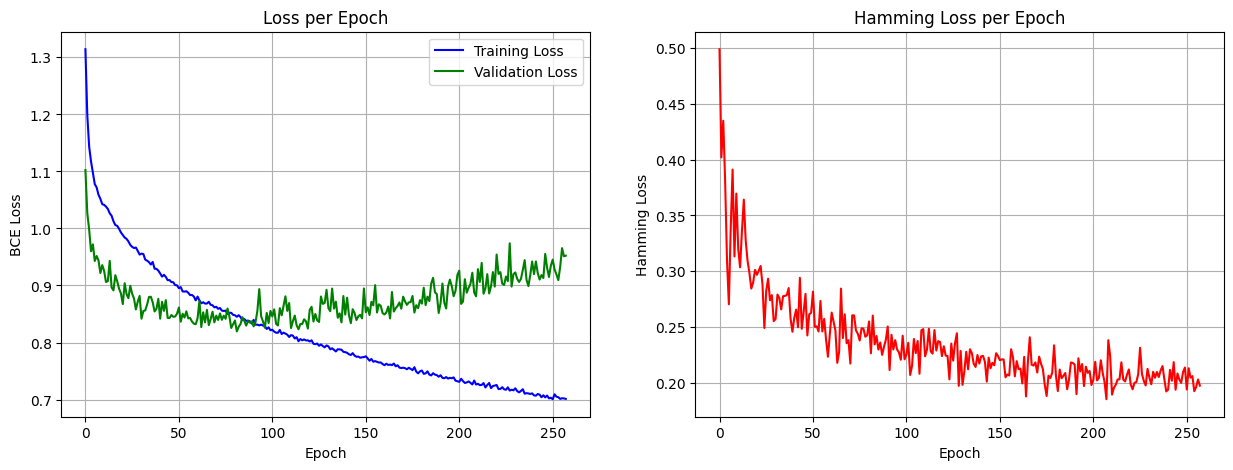

In [ ]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Training Loss
ax1.plot(loss_history, label='Training Loss', color='blue')
ax1.plot(val_loss_history, label='Validation Loss', color='green')
ax1.set_title('Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.grid(True)
ax1.legend()

# Hamming Loss
ax2.plot(hamming_history, label='Test Hamming Loss', color='red')
ax2.set_title('Hamming Loss per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Hamming Loss')
ax2.grid(True)

plt.show()

###Evaluating the model on the Test Set

#### Some metrics calculations

In [ ]:
print("\n--- Final Test Set Evaluation ---")
test_hamming, test_f1, test_acc = evaluate_model(test_loader, model)

print(f"Hamming Loss: {test_hamming:.4f} (Lower is better)")
print(f"Micro F1 Score: {test_f1:.4f} (Higher is better)")
print(f"Subset Accuracy: {test_acc:.4f} (Strict exact match)")

# Interpretation Check
print(f"\nInterpretation: On average, the model predicts {test_hamming*100:.2f}% of the 138 smell labels incorrectly.")


--- Final Test Set Evaluation ---
Hamming Loss: 0.1815 (Lower is better)
Micro F1 Score: 0.1436 (Higher is better)
Subset Accuracy: 0.0421 (Strict exact match)

Interpretation: On average, the model predicts 18.15% of the 138 smell labels incorrectly.


####Top k Predictions method (Google)

In [ ]:
def get_top_k_predictions(model, loader, smell_names, k=3):
    model.eval()
    results = []

    with torch.no_grad():
        for batch in loader:
            logits = model(batch)

            probs = torch.sigmoid(logits)
            top_probs, top_indices = torch.topk(probs, k, dim=1)

            top_probs = top_probs.cpu().numpy()
            top_indices = top_indices.cpu().numpy()

            for i in range(batch.num_graphs):
                current_names = [smell_names[idx] for idx in top_indices[i]]
                current_probs = top_probs[i]

                results.append(list(zip(current_names, current_probs)))

    return results

In [ ]:
num_positives

tensor([ 103.,  112.,  116.,   83.,   53.,   97.,   77.,  290.,   73.,   71.,
         257.,  119.,   40.,   27.,  131.,   57.,   29.,   40.,  176.,  129.,
          46.,  113.,  211.,   34.,   31.,   25.,  181.,   80.,   61.,   59.,
         327.,   80.,   29.,  113.,   84.,  103.,  110.,   69.,   63.,   49.,
          55.,  173.,   39.,  111.,  127.,  286.,  279.,  538.,  145.,   74.,
         886.,  459.,   49., 1664.,  113.,   34.,   52.,   84.,   45.,   61.,
        1246.,   32.,   68.,   49.,  633.,  148.,   51.,   77.,   49.,   47.,
          56.,   40.,  114.,   50.,   70.,   51.,   29.,  273.,   71.,  118.,
         110.,   72.,  182.,   31.,   89.,   60.,  188.,   52.,  323.,  123.,
         362.,  157.,   90.,   27.,   42.,   27.,   87.,  117.,  169.,   62.,
         193.,   54.,   29.,   52.,  137.,  190.,   54.,   32.,   82.,  260.,
         272.,   84.,   12.,  114.,  100.,   70.,   44.,   58.,   69.,  391.,
          45.,  359.,   36., 1291.,   50.,   42.,   86.,   36., 

In [ ]:
# getting the name of all the columns in df and putting them on a list
smell_list = df.columns[2:].tolist()

In [ ]:
# getting the list of most frequent label to the least based on smell_list and num_positives
most_frequent_smells = [smell for _, smell in sorted(zip(num_positives, smell_list), reverse=True)]

In [ ]:
most_frequent_smells[0]

'fruity'

In [ ]:
k = 10
top_predictions = get_top_k_predictions(model, test_loader, smell_list, k)

In [ ]:
which_molecule = 300

smells_in_this_molecule = []

for i in range(len(test_data[which_molecule].y)):
  if (test_data[which_molecule].y[i] == 1):
    smells_in_this_molecule.append(smell_list[i])

print(f"Top {k} predictions for molecule {which_molecule}:")

for i in range(k):
  print(f"{i+1}. {top_predictions[which_molecule][i][0]} ({top_predictions[which_molecule][i][1]*100:.2f}%)")

print(f"\nActual labels for molecule {which_molecule}:")
print(test_data[which_molecule].y, "\n")

print("Actual labels for molecule " + str(which_molecule) + " (names):", end = "")
print(smells_in_this_molecule)

Top 10 predictions for molecule 300:
1. muguet (98.66%)
2. lily (96.22%)
3. citrus (93.98%)
4. lemon (91.55%)
5. clean (89.34%)
6. orange (89.31%)
7. solvent (84.21%)
8. soapy (83.38%)
9. odorless (83.11%)
10. ozone (83.08%)

Actual labels for molecule 300:
tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]) 

Actual labels for molecule 300 (names):['animal', 'woody']


#### AUROC and AUPRC

In [ ]:
from sklearn.metrics import roc_curve, auc

model.eval()
y_true_list = []
y_score_list = []

print("Generating predictions for ROC Curve...")

with torch.no_grad():
    for batch in test_loader:
        # Raw logits
        out = model(batch)

        # Sigmoid
        probs = torch.sigmoid(out)

        # Store
        y_true_list.append(batch.y.view(batch.num_graphs, -1).cpu().numpy())
        y_score_list.append(probs.cpu().numpy())

# Stacking into big matrices
y_true = np.vstack(y_true_list)
y_score = np.vstack(y_score_list)

Generating predictions for ROC Curve...


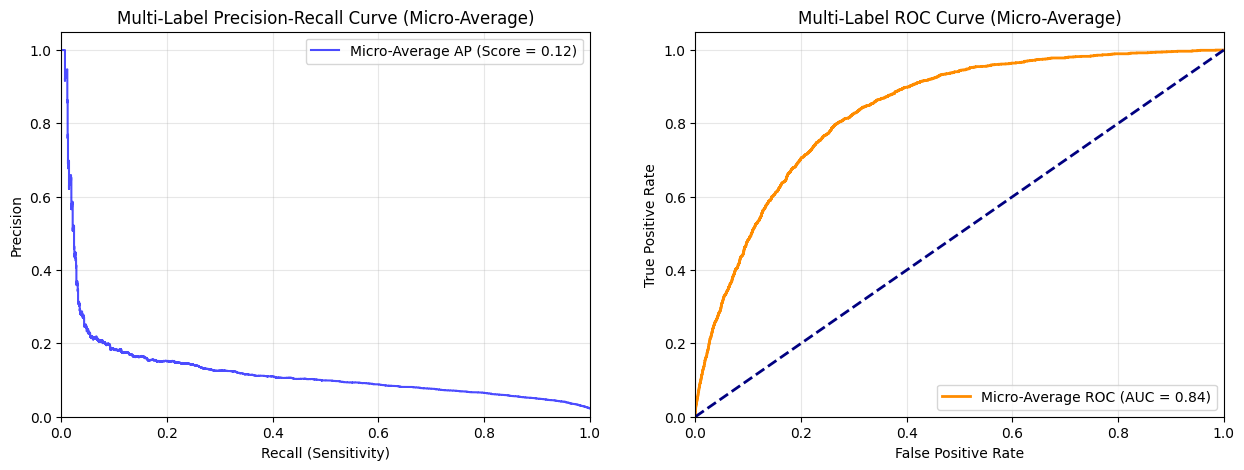

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Calculate Micro-Average ROC
fpr, tpr, _ = roc_curve(y_true.ravel(), y_score.ravel())
roc_auc = auc(fpr, tpr)

# Calculate Micro-Average Precision-Recall
precision, recall, _ = precision_recall_curve(y_true.ravel(), y_score.ravel())

# Calculate the Average Precision (AP) Score (The area under this curve)
average_precision = average_precision_score(y_true, y_score, average="micro")

# Plot the PR Curve
ax1.step(recall, precision, color='b', alpha=0.7, where='post', label=f'Micro-Average AP (Score = {average_precision:.2f})')

ax1.set_xlabel('Recall (Sensitivity)')
ax1.set_ylabel('Precision')
ax1.set_ylim([0.0, 1.05])
ax1.set_xlim([0.0, 1.0])
ax1.set_title('Multi-Label Precision-Recall Curve (Micro-Average)')
ax1.legend(loc="upper right")
ax1.grid(alpha=0.3)

# Plot the actual curve
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'Micro-Average ROC (AUC = {roc_auc:.2f})')

# Plot the "Random Guess" diagonal line (dashed)
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Multi-Label ROC Curve (Micro-Average)')
ax2.legend(loc="lower right")
ax2.grid(alpha=0.3)

plt.show()

Best Class Index: 54 (AUC: 0.9987)
Worst Class Index: 127 (AUC: 0.1406)
Mean AUC across all classes: 0.7733


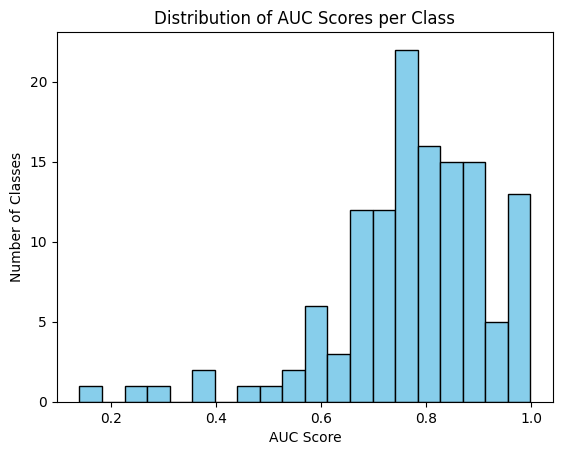

In [ ]:
# Calculate AUC for each of the 138 classes individually
class_aucs = []

for i in range(y_true.shape[1]):
    # Only calculate if the class actually exists in the test set
    if np.sum(y_true[:, i]) > 0:
        class_fpr, class_tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
        class_auc = auc(class_fpr, class_tpr)
        class_aucs.append(class_auc)
    else:
        # Handle rare classes that might not be in the test set
        class_aucs.append(np.nan)

# Convert to array for easy analysis
class_aucs = np.array(class_aucs)

print(f"Best Class Index: {np.nanargmax(class_aucs)} (AUC: {np.nanmax(class_aucs):.4f})")
print(f"Worst Class Index: {np.nanargmin(class_aucs)} (AUC: {np.nanmin(class_aucs):.4f})")
print(f"Mean AUC across all classes: {np.nanmean(class_aucs):.4f}")

# Histogram of AUCs
plt.hist(class_aucs, bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of AUC Scores per Class")
plt.xlabel("AUC Score")
plt.ylabel("Number of Classes")
plt.show()

## ________________________________________________________________________________________________________________________________________________________

## Training using the parameters of the models used in found papers


## Paper 1:

>"Machine Learning for Scent: Learning Generalizable Perceptual Representations of Small Molecules"

Available on: https://arxiv.org/pdf/1910.10685

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score
import numpy as np
import torch

def calculate_all_metrics(loader, model, device, criterion, threshold=0.5):
    model.eval()
    total_loss = 0
    y_true_all = []
    y_probs_all = []
    y_pred_all = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            # Forward pass
            out = model(batch)

            # Validation Loss
            loss = criterion(out, batch.y.view(batch.num_graphs, -1).float())
            total_loss += loss.item()

            # Probabilities
            probs = torch.sigmoid(out)

            # Binary Predictions (for F1/Prec/Recall)
            preds = (probs > threshold).float()

            # Store
            y_true_all.append(batch.y.view(batch.num_graphs, -1).float())
            y_probs_all.append(probs.cpu().numpy())
            y_pred_all.append(preds.cpu().numpy())

    # Concatenate
    y_true = np.vstack(y_true_all)
    y_probs = np.vstack(y_probs_all)
    y_pred = np.vstack(y_pred_all)

    avg_loss = total_loss / len(loader)

    # try:
    auroc = roc_auc_score(y_true, y_probs, average='micro') # re-run
    # except: auroc = 0.5

    aucpr = average_precision_score(y_true, y_probs, average='micro')

    precision = precision_score(y_true, y_pred, average='micro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='micro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)

    return avg_loss, auroc, aucpr, precision, recall, f1

###Model

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_add_pool
from torch.nn import Linear, BatchNorm1d, Dropout

class SmellGCN_Paper(torch.nn.Module):
    def __init__(self, num_node_features, num_classes=138):
        super(SmellGCN_Paper, self).__init__()

        # Layers
        self.conv1 = GCNConv(num_node_features, 15)
        self.conv2 = GCNConv(15, 20)
        self.conv3 = GCNConv(20, 27)
        self.conv4 = GCNConv(27, 36)

        # Readout: 175 dim
        self.mlp_input_dim = num_node_features + 15 + 20 + 27 + 36

        # MLP
        self.mlp1 = Linear(self.mlp_input_dim, 96)
        self.bn1 = BatchNorm1d(96)
        self.drop1 = Dropout(0.47)

        self.mlp2 = Linear(96, 63)
        self.bn2 = BatchNorm1d(63)
        self.drop2 = Dropout(0.47)

        self.out = Linear(63, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x0 = x

        x1 = F.selu(self.conv1(x0, edge_index))
        x2 = F.selu(self.conv2(x1, edge_index))
        x3 = F.selu(self.conv3(x2, edge_index))
        x4 = F.selu(self.conv4(x3, edge_index))

        # Readout
        g0 = global_add_pool(x0, batch)
        g1 = global_add_pool(x1, batch)
        g2 = global_add_pool(x2, batch)
        g3 = global_add_pool(x3, batch)
        g4 = global_add_pool(x4, batch)

        # Concatenate to get that ~175 dim vector
        x = torch.cat([g0, g1, g2, g3, g4], dim=1)

        # MLP
        x = self.mlp1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.drop1(x)

        x = self.mlp2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.drop2(x)

        return self.out(x)

###Training

In [ ]:
import torch
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

number_of_classes = (df.shape[1] - 2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SmellGCN_Paper(num_node_features=df_graph[0].x.shape[1], num_classes=number_of_classes).to(device)

all_y_tensors = [data.y for data in train_data]
stacked_y_tensors = torch.stack(all_y_tensors)
num_positives = torch.sum(stacked_y_tensors, dim=0)
num_negatives = len(train_data) - num_positives
pos_weight = num_negatives / (num_positives + 1e-5) # Add epsilon to avoid div-by-zero
pos_weight = pos_weight.to(device)

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=50, T_mult=1)

history = {
    'train_loss': [],
    'val_loss': [],
    'val_auroc': [],
    'val_aucpr': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': []
}

epochs = 500
print(f"Starting Training ({epochs} epochs)...")

for epoch in range(epochs):
  model.train()
  train_loss = 0

  for batch in train_loader:
    batch = batch.to(device)
    optimizer.zero_grad()
    out = model(batch)
    loss = criterion(out, batch.y.view(batch.num_graphs, -1).float())
    loss.backward()
    optimizer.step()
    train_loss += loss.item()

  scheduler.step()
  avg_train_loss = train_loss / len(train_loader)

  val_loss, val_auroc, val_aucpr, val_prec, val_rec, val_f1 = calculate_all_metrics(val_loader, model, device, criterion)

  # Store
  history['train_loss'].append(avg_train_loss)
  history['val_loss'].append(val_loss)
  history['val_auroc'].append(val_auroc)
  history['val_aucpr'].append(val_aucpr)
  history['val_precision'].append(val_prec)
  history['val_recall'].append(val_rec)
  history['val_f1'].append(val_f1)

  if (epoch + 1) % 10 == 0:
      print(f"Epoch {epoch+1:03d} | Loss: {val_loss:.4f} | F1: {val_f1:.4f} | AUROC: {val_auroc:.4f}")

print("Training Complete.")


Starting Training (500 epochs)...
Epoch 010 | Loss: 0.8132 | F1: 0.4230 | AUROC: 0.7271
Epoch 020 | Loss: 0.7997 | F1: 0.4252 | AUROC: 0.7377
Epoch 030 | Loss: 0.7932 | F1: 0.4372 | AUROC: 0.7412
Epoch 040 | Loss: 0.7975 | F1: 0.4383 | AUROC: 0.7523
Epoch 050 | Loss: 0.7845 | F1: 0.4419 | AUROC: 0.7518
Epoch 060 | Loss: 0.8002 | F1: 0.4370 | AUROC: 0.7485
Epoch 070 | Loss: 0.8000 | F1: 0.4344 | AUROC: 0.7485
Epoch 080 | Loss: 0.7770 | F1: 0.4407 | AUROC: 0.7490
Epoch 090 | Loss: 0.7786 | F1: 0.4470 | AUROC: 0.7561
Epoch 100 | Loss: 0.7830 | F1: 0.4489 | AUROC: 0.7579
Epoch 110 | Loss: 0.7802 | F1: 0.4360 | AUROC: 0.7438
Epoch 120 | Loss: 0.7912 | F1: 0.4416 | AUROC: 0.7550
Epoch 130 | Loss: 0.7827 | F1: 0.4480 | AUROC: 0.7560
Epoch 140 | Loss: 0.7775 | F1: 0.4488 | AUROC: 0.7621
Epoch 150 | Loss: 0.7732 | F1: 0.4465 | AUROC: 0.7619
Epoch 160 | Loss: 0.7852 | F1: 0.4400 | AUROC: 0.7536
Epoch 170 | Loss: 0.7915 | F1: 0.4420 | AUROC: 0.7512
Epoch 180 | Loss: 0.7784 | F1: 0.4496 | AUROC: 0

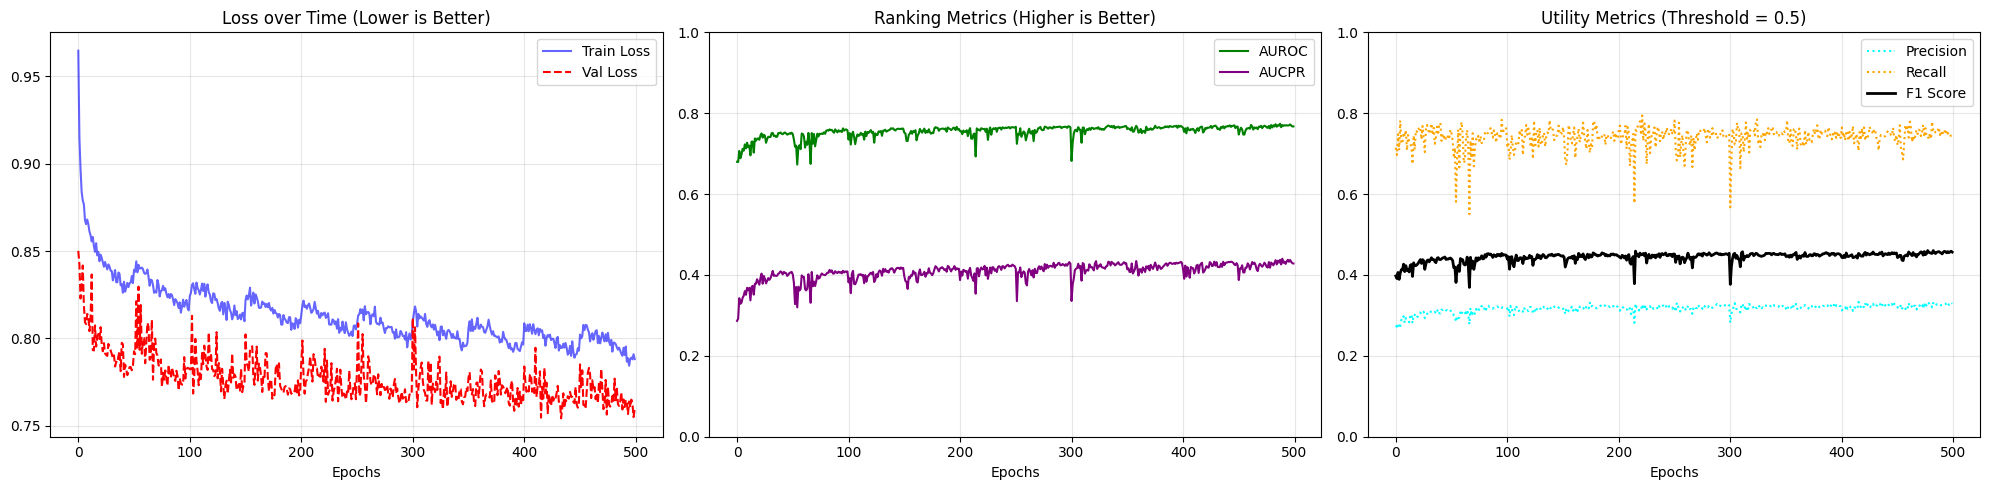

In [ ]:
import matplotlib.pyplot as plt

def plot_full_history(history):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

    ax1.plot(history['train_loss'], label='Train Loss', color='blue', alpha=0.6)
    ax1.plot(history['val_loss'], label='Val Loss', color='red', linestyle='--')
    ax1.set_title('Loss over Time (Lower is Better)')
    ax1.set_xlabel('Epochs')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax2.plot(history['val_auroc'], label='AUROC', color='green')
    ax2.plot(history['val_aucpr'], label='AUCPR', color='purple')
    ax2.set_title('Ranking Metrics (Higher is Better)')
    ax2.set_xlabel('Epochs')
    ax2.set_ylim([0, 1])
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    ax3.plot(history['val_precision'], label='Precision', color='cyan', linestyle=':')
    ax3.plot(history['val_recall'], label='Recall', color='orange', linestyle=':')
    ax3.plot(history['val_f1'], label='F1 Score', color='black', linewidth=2)
    ax3.set_title('Utility Metrics (Threshold = 0.5)')
    ax3.set_xlabel('Epochs')
    ax3.set_ylim([0, 1])
    ax3.grid(True, alpha=0.3)
    ax3.legend()

    plt.tight_layout()
    plt.show()

plot_full_history(history)

### Optimizing the threshold before testing (using the validation set for it)
- Using a single value for the optimal threshold

In [ ]:
# import numpy as np
# from sklearn.metrics import f1_score
# import torch

# def find_optimal_threshold(val_loader, model, device):
#     """
#     Sweeps through thresholds on the validation set to find the one
#     that maximizes the Micro-F1 score.
#     """
#     model.eval()
#     y_true_all = []
#     y_probs_all = []

#     # 1. Gather all probabilities from the Validation Set
#     with torch.no_grad():
#         for batch in val_loader:
#             batch = batch.to(device)
#             out = model(batch)
#             probs = torch.sigmoid(out) # Get probabilities between 0 and 1

#             y_true_all.append(batch.y.view(batch.num_graphs, -1).float())
#             y_probs_all.append(probs.cpu().numpy())

#     y_true = np.vstack(y_true_all)
#     y_probs = np.vstack(y_probs_all)

#     best_threshold = 0.5
#     best_f1 = 0.0

#     print("Sweeping thresholds...")

#     # 2. Test every threshold from 0.01 to 0.99 in increments of 0.01
#     thresholds_to_test = np.arange(0.01, 1.0, 0.01)

#     for thresh in thresholds_to_test:
#         # Convert probabilities to binary predictions using the current threshold
#         y_pred = (y_probs >= thresh).astype(int)

#         # Calculate Micro-F1
#         current_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)

#         # Keep track of the best one
#         if current_f1 > best_f1:
#             best_f1 = current_f1
#             best_threshold = thresh

#     print(f"Optimal Threshold Found: {best_threshold:.2f} (Val F1: {best_f1:.4f})")
#     return best_threshold

In [ ]:
# optimal_threshold = find_optimal_threshold(val_loader, model, device)

Sweeping thresholds...
Optimal Threshold Found: 0.75 (Val F1: 0.2641)


### Testing

In [ ]:
# def calculate_all_metrics(loader, model, device, criterion, threshold=0.5):
#     model.eval()
#     total_loss = 0
#     y_true_all = []
#     y_probs_all = []
#     y_pred_all = []

#     with torch.no_grad():
#         for batch in loader:
#             batch = batch.to(device)

#             # Forward pass
#             out = model(batch)

#             # Validation Loss
#             loss = criterion(out, batch.y.view(batch.num_graphs, -1).float())
#             total_loss += loss.item()

#             # Probabilities
#             probs = torch.sigmoid(out)

#             # Binary Predictions (for F1/Prec/Recall)
#             preds = (probs > threshold).float()

#             # Store
#             y_true_all.append(batch.y.view(batch.num_graphs, -1).float())
#             y_probs_all.append(probs.cpu().numpy())
#             y_pred_all.append(preds.cpu().numpy())

#     # Concatenate
#     y_true = np.vstack(y_true_all)
#     y_probs = np.vstack(y_probs_all)
#     y_pred = np.vstack(y_pred_all)

#     avg_loss = total_loss / len(loader)

#     # try:
#     auroc = roc_auc_score(y_true, y_probs, average='micro') # re-run
#     # except: auroc = 0.5

#     aucpr = average_precision_score(y_true, y_probs, average='micro')

#     precision = precision_score(y_true, y_pred, average='micro', zero_division=0)
#     recall = recall_score(y_true, y_pred, average='micro', zero_division=0)
#     f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)

#     return avg_loss, auroc, aucpr, precision, recall, f1

In [ ]:
# _, test_auroc, _, test_prec, test_rec, test_f1 = calculate_all_metrics(test_loader, model, device, criterion, optimal_threshold)

# print(f"{'AUROC':<10} | {'Precision':<10} | {'Recall':<10} | {'F1 Score':<10}")
# print("-" * 46)
# print(f"{test_auroc:<10.4f} | {test_prec:<10.4f} | {test_rec:<10.4f} | {test_f1:<10.4f}")
# print("-" * 46)

AUROC      | Precision  | Recall     | F1 Score  
----------------------------------------------
0.8561     | 0.1974     | 0.3825     | 0.2604    
----------------------------------------------


In [ ]:
# print("\nInterpretation:")
# print(f"- AUROC ({test_auroc:.2f}): Global ranking capability.")
# print(f"- Precision ({test_prec:.2f}): Reliability (How many predicted smells are real?).")
# print(f"- Recall ({test_rec:.2f}): Sensitivity (How many real smells did we find?).")

### Optimizing the threshold before testing (using the validation set for it)
  - Using one threshold adjusted for each label

In [ ]:
import numpy as np
from sklearn.metrics import f1_score
import torch

def find_per_label_thresholds(val_loader, model, device, num_classes=138):
    model.eval()
    y_true_all = []
    y_probs_all = []

    # 1. Gather all probabilities from the Validation Set
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch)
            probs = torch.sigmoid(out)

            y_true_all.append(batch.y.view(batch.num_graphs, -1).float())
            y_probs_all.append(probs.cpu().numpy())

    y_true = np.vstack(y_true_all)
    y_probs = np.vstack(y_probs_all)

    # Initialize an array to hold the 138 best thresholds (default to 0.5)
    best_thresholds = np.full(num_classes, 0.5)

    print(f"Sweeping thresholds for all {num_classes} labels individually...")

    # 2. Loop through each smell label (column)
    for class_idx in range(num_classes):
        # Isolate the true labels and probabilities for THIS specific smell
        y_true_class = y_true[:, class_idx]
        y_probs_class = y_probs[:, class_idx]

        # Safety check: If a smell doesn't exist in the validation set at all, skip it
        if np.sum(y_true_class) == 0:
            continue

        best_f1 = 0.0
        best_thresh = 0.5

        # Test thresholds for this specific smell
        for thresh in np.arange(0.01, 1.0, 0.01):
            y_pred_class = (y_probs_class >= thresh).astype(int)

            # Calculate the F1 score for this class only
            current_f1 = f1_score(y_true_class, y_pred_class, zero_division=0)

            if current_f1 > best_f1:
                best_f1 = current_f1
                best_thresh = thresh

        # Save the winning threshold for this smell
        best_thresholds[class_idx] = best_thresh

    print("Done! Found 138 optimal thresholds.")
    return best_thresholds

In [ ]:
optimal_thresholds = find_per_label_thresholds(val_loader, model, device, num_classes = number_of_classes)

Sweeping thresholds for all 12 labels individually...
Done! Found 138 optimal thresholds.


In [ ]:
thresholds_tensor = torch.tensor(optimal_thresholds, dtype=torch.float32).to(device)

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score, accuracy_score

def calculate_all_metrics_thresh(loader, model, device, criterion, threshold=0.5):
    model.eval()
    total_loss = 0
    y_true_all = []
    y_probs_all = []
    y_pred_all = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            # Forward pass
            out = model(batch)

            # Validation Loss
            loss = criterion(out, batch.y.view(batch.num_graphs, -1).float())
            total_loss += loss.item()

            # Probabilities
            probs = torch.sigmoid(out)

            # Binary Predictions (for F1/Prec/Recall)
            preds = (probs > threshold).float()

            # Store
            y_true_all.append(batch.y.view(batch.num_graphs, -1).float())
            y_probs_all.append(probs.cpu().numpy())
            y_pred_all.append(preds.cpu().numpy())

    # Concatenate
    y_true = np.vstack(y_true_all)
    y_probs = np.vstack(y_probs_all)
    y_pred = np.vstack(y_pred_all)

    avg_loss = total_loss / len(loader)

    # try:
    auroc = roc_auc_score(y_true, y_probs, average='micro') # re-run
    # except: auroc = 0.5

    aucpr = average_precision_score(y_true, y_probs, average='micro')

    precision = precision_score(y_true, y_pred, average='micro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='micro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)

    return avg_loss, auroc, aucpr, precision, recall, f1, accuracy

In [ ]:
_, test_auroc, _, test_prec, test_rec, test_f1, test_acc = calculate_all_metrics_thresh(test_loader, model, device, criterion, thresholds_tensor)

print(f"{'AUROC':<10} | {'Precision':<10} | {'Recall':<10} | {'F1 Score':<10} | {'Accuracy':<10}")
print("-" * 60)
print(f"{test_auroc:<10.4f} | {test_prec:<10.4f} | {test_rec:<10.4f} | {test_f1:<10.4f} | {test_acc:<10.4f}")
print("-" * 60)

AUROC      | Precision  | Recall     | F1 Score   | Accuracy  
------------------------------------------------------------
0.7530     | 0.3949     | 0.6298     | 0.4855     | 0.0942    
------------------------------------------------------------


Testing for the new molecules:

In [ ]:
new_molecules

array(['CC(C)/C=C/C=C(\\C)/C=C', 'CC1=CCC2C(C1)C2(C)C',
       'CC(=CCCC(C)(C=C)O)C', 'CC1=C[C@H]2C[C@@H](C1)C2(C)C',
       'CC1=CC[C@H](CC1)C(=C)C', 'CC1=CC[C@@H](CC1)C(=C)C'], dtype=object)

In [ ]:
new_molecules_smells = []

for i in new_molecules:
  new_molecule_data = from_smiles(i, with_hydrogen=0)
  new_molecule_data.x = new_molecule_data.x.float()
  new_molecule_data = new_molecule_data.to(device)
  testing = model(new_molecule_data)
  probs = torch.sigmoid(testing)
  preds = (probs > thresholds_tensor).float()
  new_molecules_smells.append(preds)

  predicted_smells_indices = (preds.squeeze() == 1).nonzero(as_tuple=True)[0]
  predicted_smell_names = df.columns[2:][predicted_smells_indices].tolist()
  print("Predicted smells for ", i, ":\n\t", predicted_smell_names, sep = '')

Predicted smells for CC(C)/C=C/C=C(\C)/C=C:
	['floral', 'fruity', 'woody', 'green', 'spicy', 'citrus']
Predicted smells for CC1=CCC2C(C1)C2(C)C:
	['woody', 'green', 'spicy', 'citrus']
Predicted smells for CC(=CCCC(C)(C=C)O)C:
	['floral', 'fruity', 'woody', 'green', 'citrus']
Predicted smells for CC1=C[C@H]2C[C@@H](C1)C2(C)C:
	['woody', 'green', 'spicy', 'citrus']
Predicted smells for CC1=CC[C@H](CC1)C(=C)C:
	['floral', 'woody', 'green', 'spicy', 'citrus']
Predicted smells for CC1=CC[C@@H](CC1)C(=C)C:
	['floral', 'woody', 'green', 'spicy', 'citrus']


# Using the 138 smells individually

## **Dataset Preprocessing**

## Importing the dataset

In [ ]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/fperone/Projet_IA-Generative-pour-la-decouverte-moleculaire/refs/heads/main/Multi-Labelled_Smiles_Odors_dataset.csv')

df.head()

,nonStereoSMILES,descriptors,alcoholic,aldehydic,alliaceous,almond,amber,animal,anisic,apple,...,tropical,vanilla,vegetable,vetiver,violet,warm,waxy,weedy,winey,woody
0,CC(O)CN,fishy,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,CCC(=O)C(=O)O,fatty;lactonic;sweet;caramellic;creamy,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,O=C(O)CCc1ccccc1,rose;floral;fatty;sweet;musk;cinnamon;balsamic,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,OCc1ccc(O)cc1,medicinal;phenolic;fruity;nutty;bitter;sweet;a...,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,O=Cc1ccc(O)cc1,phenolic;woody;nutty;vanilla;hay;metallic;swee...,0,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1


In [ ]:
df_new_dataset = pd.read_csv('7Q27.normalized.signatures_with_smiles.csv')
df_new_dataset = df_new_dataset.head(-3)['SMILES']
new_molecules = df_new_dataset.unique()
new_molecules

array(['CC(C)/C=C/C=C(\\C)/C=C', 'CC1=CCC2C(C1)C2(C)C',
       'CC(=CCCC(C)(C=C)O)C', 'CC1=C[C@H]2C[C@@H](C1)C2(C)C',
       'CC1=CC[C@H](CC1)C(=C)C', 'CC1=CC[C@@H](CC1)C(=C)C'], dtype=object)

In [ ]:
df.shape

(4983, 140)

In [ ]:
df.iloc[:, 2:].values

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

## Checking for NaNs in the dataset

In [ ]:
df.isna().sum()

,0
nonStereoSMILES,0
descriptors,0
alcoholic,0
aldehydic,0
alliaceous,0
...,...
warm,0
waxy,0
weedy,0
winey,0


Substituting NaNs for Zeros

In [ ]:
df.fillna(0, inplace=True)
df.isna().sum()

,0
nonStereoSMILES,0
descriptors,0
alcoholic,0
aldehydic,0
alliaceous,0
...,...
warm,0
waxy,0
weedy,0
winey,0


## Converting the SMILES representation to a graph one

### Example of a molecule with RDKit

In [ ]:
# smiles = df['nonStereoSMILES'][4980]

In [ ]:
# smiles

'CC1CCC(C(C)C)C(OCC(C)(O)CO)C1'

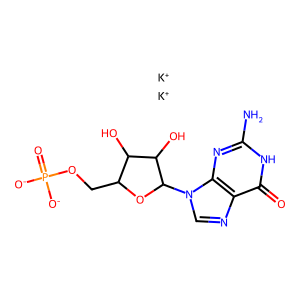

In [ ]:
# from rdkit import Chem
# from rdkit.Chem import AllChem, Draw, PandasTools, Descriptors

# mol = Chem.MolFromSmiles(smiles)
# img = Chem.Draw.MolToImage(mol)
# img

### Converting the SMILES to graphs with `from_smiles`

In [ ]:
import torch
from torch_geometric.utils import from_smiles
from torch_geometric.utils import to_networkx

df_graph = []
labels = []
G = []

for i in range(len(df)):
  smiles = df['nonStereoSMILES'][i]
  data = from_smiles(smiles, with_hydrogen=0)
  data.x = data.x.float()
  data.y = torch.tensor(df.iloc[i, 2:], dtype=torch.float)
  df_graph.append(data)
  G.append(to_networkx(data, to_undirected=True))
  labels.append(df.iloc[i, 2:])

/tmp/ipykernel_16275/3099259129.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data.y = torch.tensor(df.iloc[i, 2:], dtype=torch.float)
/tmp/ipykernel_16275/3099259129.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data.y = torch.tensor(df.iloc[i, 2:], dtype=torch.float)
/tmp/ipykernel_16275/3099259129.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data.y = torch.tensor(df.iloc[i, 2:], dtype=torch.float)
/tmp/ipyke

### Building the H matrix mannualy

In [ ]:
# smiles_list = df['nonStereoSMILES'].tolist()

#### Checking for the number of unique atoms in the dataset by utilising the SMILES representation:

In [ ]:
# import torch
# import pandas as pd
# import numpy as np
# from rdkit import Chem
# from torch_geometric.data import Data, InMemoryDataset
# from tqdm import tqdm

# def get_unique_atoms(smiles_list):
#     """
#     Scans the entire list of SMILES to find which atoms exist in the dataset.
#     """
#     unique_atoms = set()
#     print(f"Scanning {len(smiles_list)} molecules for unique atoms...")

#     for smiles in tqdm(smiles_list):
#         mol = Chem.MolFromSmiles(smiles)
#         if mol is None: continue
#         for atom in mol.GetAtoms():
#             unique_atoms.add(atom.GetSymbol())

#     sorted_atoms = sorted(list(unique_atoms))
#     print(f"Found {len(sorted_atoms)} unique atoms: {sorted_atoms}")
#     return sorted_atoms

In [ ]:
# atoms_list = get_unique_atoms(smiles_list)

In [ ]:
# atoms_list

### Testing some stuff

In [ ]:
# G[4980].number_of_nodes(), G[4980].number_of_edges(), list(G[4980].edges)

(26,
 26,
 [(0, 1),
  (1, 2),
  (1, 23),
  (2, 3),
  (3, 4),
  (3, 7),
  (4, 5),
  (4, 21),
  (5, 6),
  (6, 7),
  (7, 8),
  (8, 9),
  (8, 19),
  (9, 10),
  (10, 11),
  (10, 17),
  (11, 12),
  (12, 13),
  (13, 14),
  (13, 15),
  (13, 16),
  (17, 18),
  (17, 19),
  (19, 20),
  (21, 22),
  (21, 23)])

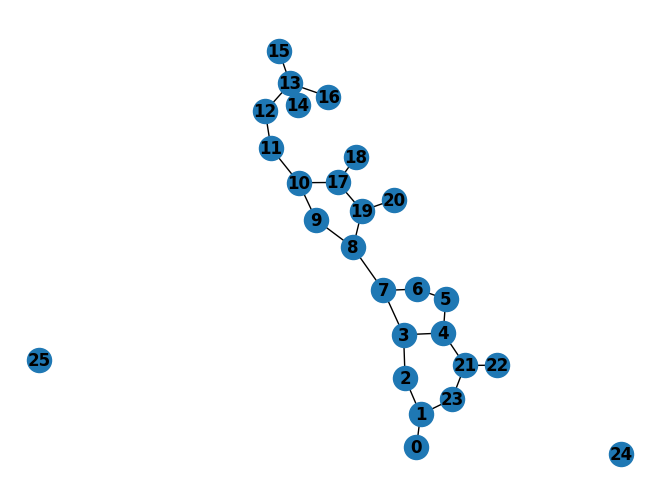

In [ ]:
# import networkx as nx

# nx.draw(G[4980], with_labels=True, font_weight='bold')

Separate the features in x and the labels in y

In [ ]:
# # Separate features (X) and labels (y)
# X = preprocessed_df  # Features
# y = df.iloc[:, 2:] # Labels

# display(X.head())
# display(y.head())

**texte en gras**# **GNN Implementation**

## Creating the train and test loaders

In [ ]:
!pip install scikit-multilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 4.8 MB/s eta 0:00:00


### Second-order iterative stratification

In [ ]:
import numpy as np
import pandas as pd
from skmultilearn.model_selection import IterativeStratification
from torch_geometric.loader import DataLoader
import torch

def create_stratified_splits(df, label_columns, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1):
    X = np.arange(len(df)).reshape(-1, 1)
    y = label_columns

    holdout_ratio = val_ratio + test_ratio

    stratifier_1 = IterativeStratification(
        n_splits=2,
        order=2,
        sample_distribution_per_fold=[holdout_ratio, train_ratio]
    )

    train_idx, holdout_idx = next(stratifier_1.split(X, y))

    print(f"   -> Step 1 Complete: {len(train_idx)} Train samples, {len(holdout_idx)} Holdout samples.")

    relative_test_ratio = test_ratio / holdout_ratio
    relative_val_ratio = 1.0 - relative_test_ratio

    stratifier_2 = IterativeStratification(
        n_splits=2,
        order=2,
        sample_distribution_per_fold=[relative_test_ratio, relative_val_ratio]
    )

    X_holdout = X[holdout_idx]
    y_holdout = y[holdout_idx]

    val_idx_relative, test_idx_relative = next(stratifier_2.split(X_holdout, y_holdout))

    val_idx = holdout_idx[val_idx_relative]
    test_idx = holdout_idx[test_idx_relative]

    print(f"   -> Step 2 Complete: {len(val_idx)} Val samples, {len(test_idx)} Test samples.")

    df_train = df.iloc[train_idx].copy()
    df_val = df.iloc[val_idx].copy()
    df_test = df.iloc[test_idx].copy()

    return df_train, df_val, df_test


train_data, val_data, test_data = create_stratified_splits(
    df=df,
    label_columns=df.iloc[:, 2:].values,
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1
)

df_graph_train = []
df_graph_val = []
df_graph_test = []
labels_train = []
labels_val = []
labels_test = []
G = []

for i in range(len(train_data)):
  smiles = train_data['nonStereoSMILES'].iloc[i]
  data = from_smiles(smiles, with_hydrogen=0)
  data.x = data.x.float()
  data.y = torch.tensor(train_data.iloc[i, 2:], dtype=torch.float)
  df_graph_train.append(data)
  G.append(to_networkx(data, to_undirected=True))
  labels_train.append(train_data.iloc[i, 2:])

for i in range(len(val_data)):
  smiles = val_data['nonStereoSMILES'].iloc[i]
  data = from_smiles(smiles, with_hydrogen=0)
  data.x = data.x.float()
  data.y = torch.tensor(val_data.iloc[i, 2:], dtype=torch.float)
  df_graph_val.append(data)
  G.append(to_networkx(data, to_undirected=True))
  labels_val.append(val_data.iloc[i, 2:])

for i in range(len(test_data)):
  smiles = test_data['nonStereoSMILES'].iloc[i]
  data = from_smiles(smiles, with_hydrogen=0)
  data.x = data.x.float()
  data.y = torch.tensor(test_data.iloc[i, 2:], dtype=torch.float)
  df_graph_test.append(data)
  G.append(to_networkx(data, to_undirected=True))
  labels_test.append(test_data.iloc[i, 2:])

train_data = df_graph_train
val_data = df_graph_val
test_data = df_graph_test

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False) # no shuffle needed for eval
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False)

   -> Step 1 Complete: 3964 Train samples, 1019 Holdout samples.
   -> Step 2 Complete: 512 Val samples, 507 Test samples.


/tmp/ipykernel_16275/439607195.py:69: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data.y = torch.tensor(train_data.iloc[i, 2:], dtype=torch.float)
/tmp/ipykernel_16275/439607195.py:69: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data.y = torch.tensor(train_data.iloc[i, 2:], dtype=torch.float)
/tmp/ipykernel_16275/439607195.py:69: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data.y = torch.tensor(train_data.iloc[i, 2:], dtype=to

### Splits (not using second-order iterative stratification)

In [ ]:
# from torch_geometric.loader import DataLoader
# import torch

# # splitting the dataset into train and test sets
# total_size = len(df_graph)
# train_size = int(total_size * 0.8)  # 80% for training
# val_size   = int(total_size * 0.1)  # 10% for validation
# test_size  = total_size - train_size - val_size # 10% for test

# # perform the split
# train_data = df_graph[:train_size]
# val_data   = df_graph[train_size : train_size + val_size]
# test_data  = df_graph[train_size + val_size :]

# # create loaders
# train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
# val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False) # no shuffle needed for eval
# test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False)

# len(train_data), len(val_data), len(test_data)

(3986, 498, 499)

## **GNN Implementation**

## Model Creation

### GCN Model

#### Global mean pool

##### 2 GCN Layers

In [ ]:
# import torch.nn.functional as F
# from torch_geometric.nn import GCNConv, global_mean_pool

# class SmellPredictor(torch.nn.Module):
#     def __init__(self, num_node_features, num_classes=138):
#         super(SmellPredictor, self).__init__()

#         self.conv1 = GCNConv(num_node_features, 64)
#         self.conv2 = GCNConv(64, 128)
#         # self.conv3 = GCNConv(128, 128)

#         self.lin = torch.nn.Linear(128, num_classes)

#     def forward(self, data):
#         x, edge_index, batch = data.x, data.edge_index, data.batch

#         x = self.conv1(x, edge_index)
#         x = F.relu(x)
#         x = self.conv2(x, edge_index)
#         # x = F.relu(x)
#         # x = self.conv3(x, edge_index)

#         x = global_mean_pool(x, batch)

#         x = self.lin(x)

#         return x

##### 3 GCN Layers

In [ ]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class SmellPredictor(torch.nn.Module):
    def __init__(self, num_node_features, num_classes=138):
        super(SmellPredictor, self).__init__()

        self.conv1 = GCNConv(num_node_features, 64)
        self.conv2 = GCNConv(64, 128)
        self.conv3 = GCNConv(128, 128)

        self.lin = torch.nn.Linear(128, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)

        x = global_mean_pool(x, batch)

        x = self.lin(x)

        return x

##### 4 GCN Layers

In [ ]:
# import torch.nn.functional as F
# from torch_geometric.nn import GCNConv, global_mean_pool

# class SmellPredictor(torch.nn.Module):
#     def __init__(self, num_node_features, num_classes=138):
#         super(SmellPredictor, self).__init__()

#         self.conv1 = GCNConv(num_node_features, 64)
#         self.conv2 = GCNConv(64, 128)
#         self.conv3 = GCNConv(128, 256) # changed this layer to fit the fourth layer
#         self.conv4 = GCNConv(256, 128) # new layer

#         self.lin = torch.nn.Linear(128, num_classes)

#     def forward(self, data):
#         x, edge_index, batch = data.x, data.edge_index, data.batch

#         x = self.conv1(x, edge_index)
#         x = F.relu(x)
#         x = self.conv2(x, edge_index)
#         x = F.relu(x)
#         x = self.conv3(x, edge_index)
#         x = F.relu(x)
#         x = self.conv4(x, edge_index)

#         x = global_mean_pool(x, batch)

#         x = self.lin(x)

#         return x

#### Global max pool

##### 2 GCN Layers

In [ ]:
# import torch.nn.functional as F
# from torch_geometric.nn import GCNConv, global_max_pool

# class SmellPredictor(torch.nn.Module):
#     def __init__(self, num_node_features, num_classes=138):
#         super(SmellPredictor, self).__init__()

#         self.conv1 = GCNConv(num_node_features, 64)
#         self.conv2 = GCNConv(64, 128)
#         # self.conv3 = GCNConv(128, 128)

#         self.lin = torch.nn.Linear(128, num_classes)

#     def forward(self, data):
#         x, edge_index, batch = data.x, data.edge_index, data.batch

#         x = self.conv1(x, edge_index)
#         x = F.relu(x)
#         x = self.conv2(x, edge_index)
#         # x = F.relu(x)
#         # x = self.conv3(x, edge_index)

#         x = global_max_pool(x, batch)

#         x = self.lin(x)

#         return x

##### 3 GCN Layers

In [ ]:
# import torch.nn.functional as F
# from torch_geometric.nn import GCNConv, global_max_pool

# class SmellPredictor(torch.nn.Module):
#     def __init__(self, num_node_features, num_classes=138):
#         super(SmellPredictor, self).__init__()

#         self.conv1 = GCNConv(num_node_features, 64)
#         self.conv2 = GCNConv(64, 128)
#         self.conv3 = GCNConv(128, 128)

#         self.lin = torch.nn.Linear(128, num_classes)

#     def forward(self, data):
#         x, edge_index, batch = data.x, data.edge_index, data.batch

#         x = self.conv1(x, edge_index)
#         x = F.relu(x)
#         x = self.conv2(x, edge_index)
#         x = F.relu(x)
#         x = self.conv3(x, edge_index)

#         x = global_max_pool(x, batch)

#         x = self.lin(x)

#         return x

##### 4 GCN Layers

In [ ]:
# import torch.nn.functional as F
# from torch_geometric.nn import GCNConv, global_max_pool

# class SmellPredictor(torch.nn.Module):
#     def __init__(self, num_node_features, num_classes=138):
#         super(SmellPredictor, self).__init__()

#         self.conv1 = GCNConv(num_node_features, 64)
#         self.conv2 = GCNConv(64, 128)
#         self.conv3 = GCNConv(128, 256) # changed this layer to fit the fourth layer
#         self.conv4 = GCNConv(256, 128) # new layer

#         self.lin = torch.nn.Linear(128, num_classes)

#     def forward(self, data):
#         x, edge_index, batch = data.x, data.edge_index, data.batch

#         x = self.conv1(x, edge_index)
#         x = F.relu(x)
#         x = self.conv2(x, edge_index)
#         x = F.relu(x)
#         x = self.conv3(x, edge_index)
#         x = F.relu(x)
#         x = self.conv4(x, edge_index)

#         x = global_max_pool(x, batch)

#         x = self.lin(x)

#         return x

#### Global add pool

Model with the same GCN parameters as the one on the paper "Machine Learning for Scent: Learning Generalizable Perceptual Representations of Small Molecules"

In [ ]:
# import torch.nn.functional as F
# from torch_geometric.nn import GCNConv, global_add_pool

# class SmellPredictor(torch.nn.Module):
#     def __init__(self, num_node_features, num_classes=138):
#         super(SmellPredictor, self).__init__()

#         self.conv1 = GCNConv(num_node_features, 15)
#         self.conv2 = GCNConv(15, 20)
#         self.conv3 = GCNConv(20, 27)
#         self.conv4 = GCNConv(27, 36)

#         self.lin = torch.nn.Linear(36, num_classes)

#     def forward(self, data):
#         x, edge_index, batch = data.x, data.edge_index, data.batch

#         x = self.conv1(x, edge_index)
#         x = F.relu(x)
#         x = self.conv2(x, edge_index)
#         x = F.relu(x)
#         x = self.conv3(x, edge_index)
#         x = F.relu(x)
#         x = self.conv4(x, edge_index)

#         x = global_add_pool(x, batch)

#         x = self.lin(x)

#         return x

### Some parameters definitions (always run before any training)

In [ ]:
# Training Setup
model = SmellPredictor(num_node_features=df_graph[0].x.shape[1])
# model = SmellGCN_Paper(num_node_features=df_graph[0].x.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### Criterion definition

#### If you want to consider the '0's to have the same weight as the '1's, use the following criterion

In [ ]:
# criterion = torch.nn.BCEWithLogitsLoss()

#### Else, if you want to the '1's to have a lot more weight when classifying the smells, use the following:

In [ ]:
all_y_tensors = [data.y for data in train_data]
stacked_y_tensors = torch.stack(all_y_tensors)

In [ ]:
num_positives = torch.sum(stacked_y_tensors, dim=0)
num_negatives = len(train_data) - num_positives

pos_weight = num_negatives / (num_positives + 1e-5)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pos_weight = pos_weight.to(device)

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

## Training the model

### Functions definitions

In [ ]:
from sklearn.metrics import hamming_loss, accuracy_score, f1_score, precision_score, recall_score
import numpy as np

def evaluate_model(loader, model, threshold=0.5):
    model.eval()

    y_true_all = []
    y_pred_all = []

    with torch.no_grad():
        for batch in loader:
            out = model(batch)

            probs = torch.sigmoid(out)

            preds = (probs > threshold).float()

            y_true_all.append(batch.y.view(batch.num_graphs, -1).cpu().numpy())
            y_pred_all.append(preds.cpu().numpy())

    y_true = np.vstack(y_true_all)
    y_pred = np.vstack(y_pred_all)

    h_loss = hamming_loss(y_true, y_pred)

    f1 = f1_score(y_true, y_pred, average='micro')

    acc = accuracy_score(y_true, y_pred)

    return h_loss, f1, acc

### Training

In [ ]:
import copy
import matplotlib.pyplot as plt

patience = 50
best_val_loss = float('inf')
patience_counter = 0
best_model_weights = None
best_val_f1 = 0
epochs = 1000

use_hamming_loss_for_early_stopping = False

loss_history = []
val_loss_history = []
hamming_history = []
f1_history = []

print(f"Starting training with Early Stopping (Patience: {patience})...")

for epoch in range(epochs):
    # TRAIN STEP
    model.train()
    train_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        out = model(batch)
        loss = criterion(out, batch.y.view(batch.num_graphs, -1).float())
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    loss_history.append(avg_train_loss)

    # VALIDATION STEP
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            out = model(batch)
            loss = criterion(out, batch.y.view(batch.num_graphs, -1).float())
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_loss_history.append(avg_val_loss)

    h_loss, f1, acc = evaluate_model(val_loader, model)
    hamming_history.append(h_loss)
    f1_history.append(f1)

    print(f"Epoch {epoch} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Hamming Loss: {h_loss:.4f} | Val F1: {f1:.4f}")

    # EARLY STOPPING LOGIC
    if use_hamming_loss_for_early_stopping:
      if avg_val_loss < best_val_loss:
          best_val_loss = avg_val_loss
          best_model_weights = copy.deepcopy(model.state_dict())
          patience_counter = 0
          print(f"   >>> New Best Model! Saving... (Val Loss: {avg_val_loss:.4f})")
      else:
          patience_counter += 1
          print(f"   >>> No improvement. Patience: {patience_counter}/{patience}")

    else:
      if f1 > best_val_f1:
        best_val_f1 = f1
        best_model_weights = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(f"   >>> New Best Model! Saving... (F1: {f1:.4f})")
      else:
          patience_counter += 1
          print(f"   >>> No improvement. Patience: {patience_counter}/{patience}")

    # BREAK CONDITION
    if patience_counter >= patience:
        print("\nEarly Stopping Triggered! Restoring best weights...")
        model.load_state_dict(best_model_weights)
        break

print("Training Complete.")

Starting training with Early Stopping (Patience: 50)...
Epoch 0 | Train Loss: 1.3143 | Val Loss: 1.1024 | Hamming Loss: 0.4990 | Val F1: 0.0659
   >>> New Best Model! Saving... (F1: 0.0659)
Epoch 1 | Train Loss: 1.1986 | Val Loss: 1.0271 | Hamming Loss: 0.4020 | Val F1: 0.0742
   >>> New Best Model! Saving... (F1: 0.0742)
Epoch 2 | Train Loss: 1.1433 | Val Loss: 0.9980 | Hamming Loss: 0.4348 | Val F1: 0.0777
   >>> New Best Model! Saving... (F1: 0.0777)
Epoch 3 | Train Loss: 1.1174 | Val Loss: 0.9599 | Hamming Loss: 0.3812 | Val F1: 0.0767
   >>> No improvement. Patience: 1/50
Epoch 4 | Train Loss: 1.0977 | Val Loss: 0.9721 | Hamming Loss: 0.3101 | Val F1: 0.0851
   >>> New Best Model! Saving... (F1: 0.0851)
Epoch 5 | Train Loss: 1.0778 | Val Loss: 0.9430 | Hamming Loss: 0.2703 | Val F1: 0.0812
   >>> No improvement. Patience: 1/50
Epoch 6 | Train Loss: 1.0720 | Val Loss: 0.9517 | Hamming Loss: 0.3390 | Val F1: 0.0893
   >>> New Best Model! Saving... (F1: 0.0893)
Epoch 7 | Train Loss: 

##Testing and evaluating the model

### Loss Plots

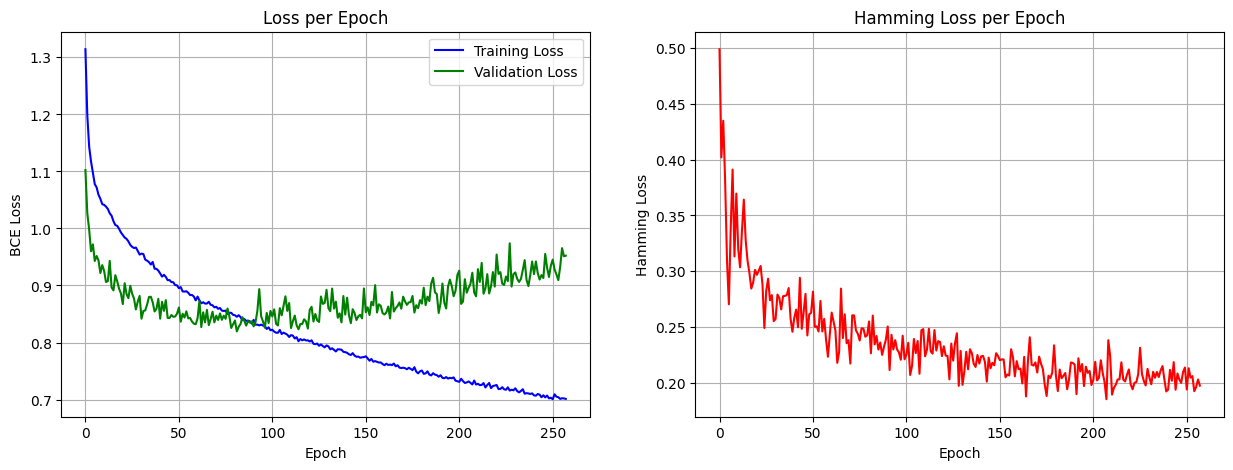

In [ ]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Training Loss
ax1.plot(loss_history, label='Training Loss', color='blue')
ax1.plot(val_loss_history, label='Validation Loss', color='green')
ax1.set_title('Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.grid(True)
ax1.legend()

# Hamming Loss
ax2.plot(hamming_history, label='Test Hamming Loss', color='red')
ax2.set_title('Hamming Loss per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Hamming Loss')
ax2.grid(True)

plt.show()

###Evaluating the model on the Test Set

#### Some metrics calculations

In [ ]:
print("\n--- Final Test Set Evaluation ---")
test_hamming, test_f1, test_acc = evaluate_model(test_loader, model)

print(f"Hamming Loss: {test_hamming:.4f} (Lower is better)")
print(f"Micro F1 Score: {test_f1:.4f} (Higher is better)")
print(f"Subset Accuracy: {test_acc:.4f} (Strict exact match)")

# Interpretation Check
print(f"\nInterpretation: On average, the model predicts {test_hamming*100:.2f}% of the 138 smell labels incorrectly.")


--- Final Test Set Evaluation ---
Hamming Loss: 0.1815 (Lower is better)
Micro F1 Score: 0.1436 (Higher is better)
Subset Accuracy: 0.0421 (Strict exact match)

Interpretation: On average, the model predicts 18.15% of the 138 smell labels incorrectly.


####Top k Predictions method (Google)

In [ ]:
def get_top_k_predictions(model, loader, smell_names, k=3):
    model.eval()
    results = []

    with torch.no_grad():
        for batch in loader:
            logits = model(batch)

            probs = torch.sigmoid(logits)
            top_probs, top_indices = torch.topk(probs, k, dim=1)

            top_probs = top_probs.cpu().numpy()
            top_indices = top_indices.cpu().numpy()

            for i in range(batch.num_graphs):
                current_names = [smell_names[idx] for idx in top_indices[i]]
                current_probs = top_probs[i]

                results.append(list(zip(current_names, current_probs)))

    return results

In [ ]:
num_positives

tensor([ 103.,  112.,  116.,   83.,   53.,   97.,   77.,  290.,   73.,   71.,
         257.,  119.,   40.,   27.,  131.,   57.,   29.,   40.,  176.,  129.,
          46.,  113.,  211.,   34.,   31.,   25.,  181.,   80.,   61.,   59.,
         327.,   80.,   29.,  113.,   84.,  103.,  110.,   69.,   63.,   49.,
          55.,  173.,   39.,  111.,  127.,  286.,  279.,  538.,  145.,   74.,
         886.,  459.,   49., 1664.,  113.,   34.,   52.,   84.,   45.,   61.,
        1246.,   32.,   68.,   49.,  633.,  148.,   51.,   77.,   49.,   47.,
          56.,   40.,  114.,   50.,   70.,   51.,   29.,  273.,   71.,  118.,
         110.,   72.,  182.,   31.,   89.,   60.,  188.,   52.,  323.,  123.,
         362.,  157.,   90.,   27.,   42.,   27.,   87.,  117.,  169.,   62.,
         193.,   54.,   29.,   52.,  137.,  190.,   54.,   32.,   82.,  260.,
         272.,   84.,   12.,  114.,  100.,   70.,   44.,   58.,   69.,  391.,
          45.,  359.,   36., 1291.,   50.,   42.,   86.,   36., 

In [ ]:
# getting the name of all the columns in df and putting them on a list
smell_list = df.columns[2:].tolist()

In [ ]:
# getting the list of most frequent label to the least based on smell_list and num_positives
most_frequent_smells = [smell for _, smell in sorted(zip(num_positives, smell_list), reverse=True)]

In [ ]:
most_frequent_smells[0]

'fruity'

In [ ]:
k = 10
top_predictions = get_top_k_predictions(model, test_loader, smell_list, k)

In [ ]:
which_molecule = 300

smells_in_this_molecule = []

for i in range(len(test_data[which_molecule].y)):
  if (test_data[which_molecule].y[i] == 1):
    smells_in_this_molecule.append(smell_list[i])

print(f"Top {k} predictions for molecule {which_molecule}:")

for i in range(k):
  print(f"{i+1}. {top_predictions[which_molecule][i][0]} ({top_predictions[which_molecule][i][1]*100:.2f}%)")

print(f"\nActual labels for molecule {which_molecule}:")
print(test_data[which_molecule].y, "\n")

print("Actual labels for molecule " + str(which_molecule) + " (names):", end = "")
print(smells_in_this_molecule)

Top 10 predictions for molecule 300:
1. muguet (98.66%)
2. lily (96.22%)
3. citrus (93.98%)
4. lemon (91.55%)
5. clean (89.34%)
6. orange (89.31%)
7. solvent (84.21%)
8. soapy (83.38%)
9. odorless (83.11%)
10. ozone (83.08%)

Actual labels for molecule 300:
tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]) 

Actual labels for molecule 300 (names):['animal', 'woody']


#### AUROC and AUPRC

In [ ]:
from sklearn.metrics import roc_curve, auc

model.eval()
y_true_list = []
y_score_list = []

print("Generating predictions for ROC Curve...")

with torch.no_grad():
    for batch in test_loader:
        # Raw logits
        out = model(batch)

        # Sigmoid
        probs = torch.sigmoid(out)

        # Store
        y_true_list.append(batch.y.view(batch.num_graphs, -1).cpu().numpy())
        y_score_list.append(probs.cpu().numpy())

# Stacking into big matrices
y_true = np.vstack(y_true_list)
y_score = np.vstack(y_score_list)

Generating predictions for ROC Curve...


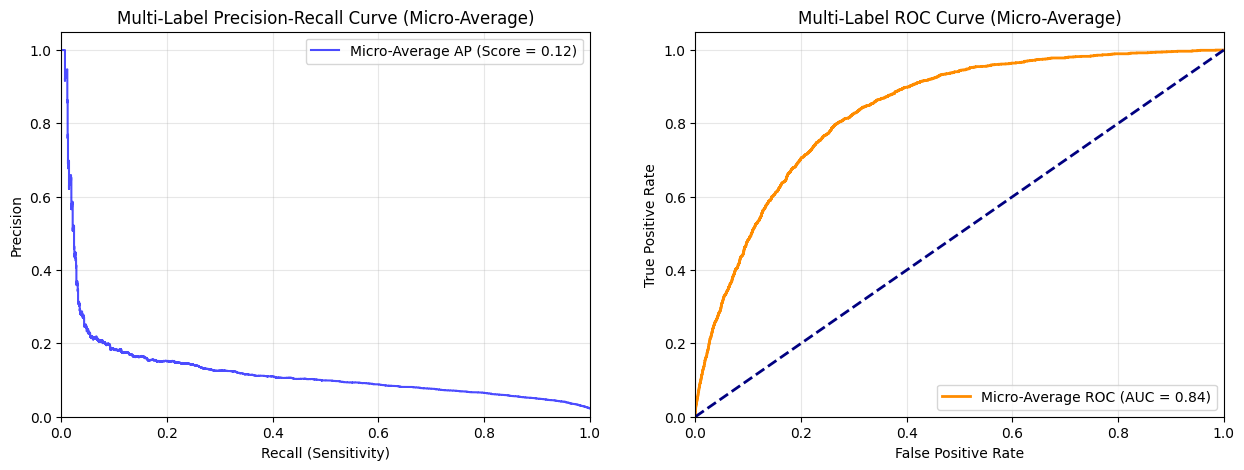

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Calculate Micro-Average ROC
fpr, tpr, _ = roc_curve(y_true.ravel(), y_score.ravel())
roc_auc = auc(fpr, tpr)

# Calculate Micro-Average Precision-Recall
precision, recall, _ = precision_recall_curve(y_true.ravel(), y_score.ravel())

# Calculate the Average Precision (AP) Score (The area under this curve)
average_precision = average_precision_score(y_true, y_score, average="micro")

# Plot the PR Curve
ax1.step(recall, precision, color='b', alpha=0.7, where='post', label=f'Micro-Average AP (Score = {average_precision:.2f})')

ax1.set_xlabel('Recall (Sensitivity)')
ax1.set_ylabel('Precision')
ax1.set_ylim([0.0, 1.05])
ax1.set_xlim([0.0, 1.0])
ax1.set_title('Multi-Label Precision-Recall Curve (Micro-Average)')
ax1.legend(loc="upper right")
ax1.grid(alpha=0.3)

# Plot the actual curve
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'Micro-Average ROC (AUC = {roc_auc:.2f})')

# Plot the "Random Guess" diagonal line (dashed)
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Multi-Label ROC Curve (Micro-Average)')
ax2.legend(loc="lower right")
ax2.grid(alpha=0.3)

plt.show()

Best Class Index: 54 (AUC: 0.9987)
Worst Class Index: 127 (AUC: 0.1406)
Mean AUC across all classes: 0.7733


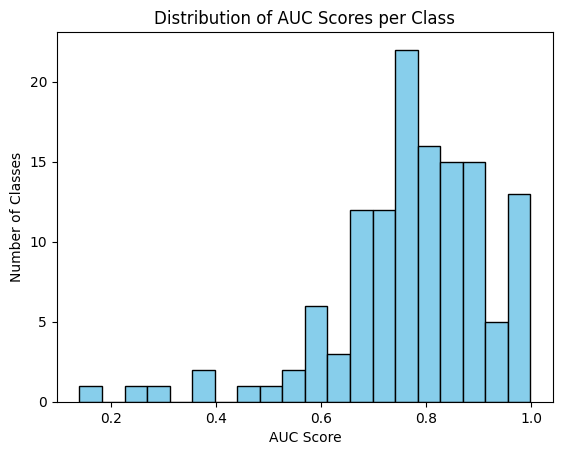

In [ ]:
# Calculate AUC for each of the 138 classes individually
class_aucs = []

for i in range(y_true.shape[1]):
    # Only calculate if the class actually exists in the test set
    if np.sum(y_true[:, i]) > 0:
        class_fpr, class_tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
        class_auc = auc(class_fpr, class_tpr)
        class_aucs.append(class_auc)
    else:
        # Handle rare classes that might not be in the test set
        class_aucs.append(np.nan)

# Convert to array for easy analysis
class_aucs = np.array(class_aucs)

print(f"Best Class Index: {np.nanargmax(class_aucs)} (AUC: {np.nanmax(class_aucs):.4f})")
print(f"Worst Class Index: {np.nanargmin(class_aucs)} (AUC: {np.nanmin(class_aucs):.4f})")
print(f"Mean AUC across all classes: {np.nanmean(class_aucs):.4f}")

# Histogram of AUCs
plt.hist(class_aucs, bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of AUC Scores per Class")
plt.xlabel("AUC Score")
plt.ylabel("Number of Classes")
plt.show()

## ________________________________________________________________________________________________________________________________________________________

## Training using the parameters of the models used in found papers


## Paper 1:

>"Machine Learning for Scent: Learning Generalizable Perceptual Representations of Small Molecules"

Available on: https://arxiv.org/pdf/1910.10685

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score
import numpy as np
import torch

def calculate_all_metrics(loader, model, device, criterion, threshold=0.5):
    model.eval()
    total_loss = 0
    y_true_all = []
    y_probs_all = []
    y_pred_all = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            # Forward pass
            out = model(batch)

            # Validation Loss
            loss = criterion(out, batch.y.view(batch.num_graphs, -1).float())
            total_loss += loss.item()

            # Probabilities
            probs = torch.sigmoid(out)

            # Binary Predictions (for F1/Prec/Recall)
            preds = (probs > threshold).float()

            # Store
            y_true_all.append(batch.y.view(batch.num_graphs, -1).float())
            y_probs_all.append(probs.cpu().numpy())
            y_pred_all.append(preds.cpu().numpy())

    # Concatenate
    y_true = np.vstack(y_true_all)
    y_probs = np.vstack(y_probs_all)
    y_pred = np.vstack(y_pred_all)

    avg_loss = total_loss / len(loader)

    # try:
    auroc = roc_auc_score(y_true, y_probs, average='micro') # re-run
    # except: auroc = 0.5

    aucpr = average_precision_score(y_true, y_probs, average='micro')

    precision = precision_score(y_true, y_pred, average='micro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='micro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)

    return avg_loss, auroc, aucpr, precision, recall, f1

###Model

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_add_pool
from torch.nn import Linear, BatchNorm1d, Dropout

class SmellGCN_Paper(torch.nn.Module):
    def __init__(self, num_node_features, num_classes=138):
        super(SmellGCN_Paper, self).__init__()

        # Layers
        self.conv1 = GCNConv(num_node_features, 15)
        self.conv2 = GCNConv(15, 20)
        self.conv3 = GCNConv(20, 27)
        self.conv4 = GCNConv(27, 36)

        # Readout: 175 dim
        self.mlp_input_dim = num_node_features + 15 + 20 + 27 + 36

        # MLP
        self.mlp1 = Linear(self.mlp_input_dim, 96)
        self.bn1 = BatchNorm1d(96)
        self.drop1 = Dropout(0.47)

        self.mlp2 = Linear(96, 63)
        self.bn2 = BatchNorm1d(63)
        self.drop2 = Dropout(0.47)

        self.out = Linear(63, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x0 = x

        x1 = F.selu(self.conv1(x0, edge_index))
        x2 = F.selu(self.conv2(x1, edge_index))
        x3 = F.selu(self.conv3(x2, edge_index))
        x4 = F.selu(self.conv4(x3, edge_index))

        # Readout
        g0 = global_add_pool(x0, batch)
        g1 = global_add_pool(x1, batch)
        g2 = global_add_pool(x2, batch)
        g3 = global_add_pool(x3, batch)
        g4 = global_add_pool(x4, batch)

        # Concatenate to get that ~175 dim vector
        x = torch.cat([g0, g1, g2, g3, g4], dim=1)

        # MLP
        x = self.mlp1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.drop1(x)

        x = self.mlp2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.drop2(x)

        return self.out(x)

###Training

In [ ]:
import torch
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

number_of_classes = 138

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SmellGCN_Paper(num_node_features=df_graph[0].x.shape[1], num_classes=number_of_classes).to(device)

all_y_tensors = [data.y for data in train_data]
stacked_y_tensors = torch.stack(all_y_tensors)
num_positives = torch.sum(stacked_y_tensors, dim=0)
num_negatives = len(train_data) - num_positives
pos_weight = num_negatives / (num_positives + 1e-5) # Add epsilon to avoid div-by-zero
pos_weight = pos_weight.to(device)

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=50, T_mult=1)

history = {
    'train_loss': [],
    'val_loss': [],
    'val_auroc': [],
    'val_aucpr': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': []
}

epochs = 500
print(f"Starting Training ({epochs} epochs)...")

for epoch in range(epochs):
  model.train()
  train_loss = 0

  for batch in train_loader:
    batch = batch.to(device)
    optimizer.zero_grad()
    out = model(batch)
    loss = criterion(out, batch.y.view(batch.num_graphs, -1).float())
    loss.backward()
    optimizer.step()
    train_loss += loss.item()

  scheduler.step()
  avg_train_loss = train_loss / len(train_loader)

  val_loss, val_auroc, val_aucpr, val_prec, val_rec, val_f1 = calculate_all_metrics(val_loader, model, device, criterion)

  # Store
  history['train_loss'].append(avg_train_loss)
  history['val_loss'].append(val_loss)
  history['val_auroc'].append(val_auroc)
  history['val_aucpr'].append(val_aucpr)
  history['val_precision'].append(val_prec)
  history['val_recall'].append(val_rec)
  history['val_f1'].append(val_f1)

  if (epoch + 1) % 10 == 0:
      print(f"Epoch {epoch+1:03d} | Loss: {val_loss:.4f} | F1: {val_f1:.4f} | AUROC: {val_auroc:.4f}")

print("Training Complete.")


Starting Training (500 epochs)...
Epoch 010 | Loss: 1.0864 | F1: 0.1402 | AUROC: 0.7981
Epoch 020 | Loss: 1.0500 | F1: 0.1513 | AUROC: 0.8071
Epoch 030 | Loss: 1.0335 | F1: 0.1549 | AUROC: 0.8107
Epoch 040 | Loss: 1.0206 | F1: 0.1579 | AUROC: 0.8188
Epoch 050 | Loss: 1.0226 | F1: 0.1567 | AUROC: 0.8172
Epoch 060 | Loss: 1.0347 | F1: 0.1622 | AUROC: 0.8160
Epoch 070 | Loss: 1.0184 | F1: 0.1579 | AUROC: 0.8172
Epoch 080 | Loss: 1.0114 | F1: 0.1642 | AUROC: 0.8245
Epoch 090 | Loss: 0.9992 | F1: 0.1668 | AUROC: 0.8304
Epoch 100 | Loss: 0.9971 | F1: 0.1694 | AUROC: 0.8315
Epoch 110 | Loss: 1.0408 | F1: 0.1626 | AUROC: 0.8200
Epoch 120 | Loss: 0.9974 | F1: 0.1701 | AUROC: 0.8292
Epoch 130 | Loss: 1.0039 | F1: 0.1748 | AUROC: 0.8389
Epoch 140 | Loss: 0.9875 | F1: 0.1749 | AUROC: 0.8373
Epoch 150 | Loss: 0.9814 | F1: 0.1748 | AUROC: 0.8397
Epoch 160 | Loss: 1.0546 | F1: 0.1709 | AUROC: 0.8182
Epoch 170 | Loss: 0.9812 | F1: 0.1715 | AUROC: 0.8331
Epoch 180 | Loss: 0.9800 | F1: 0.1760 | AUROC: 0

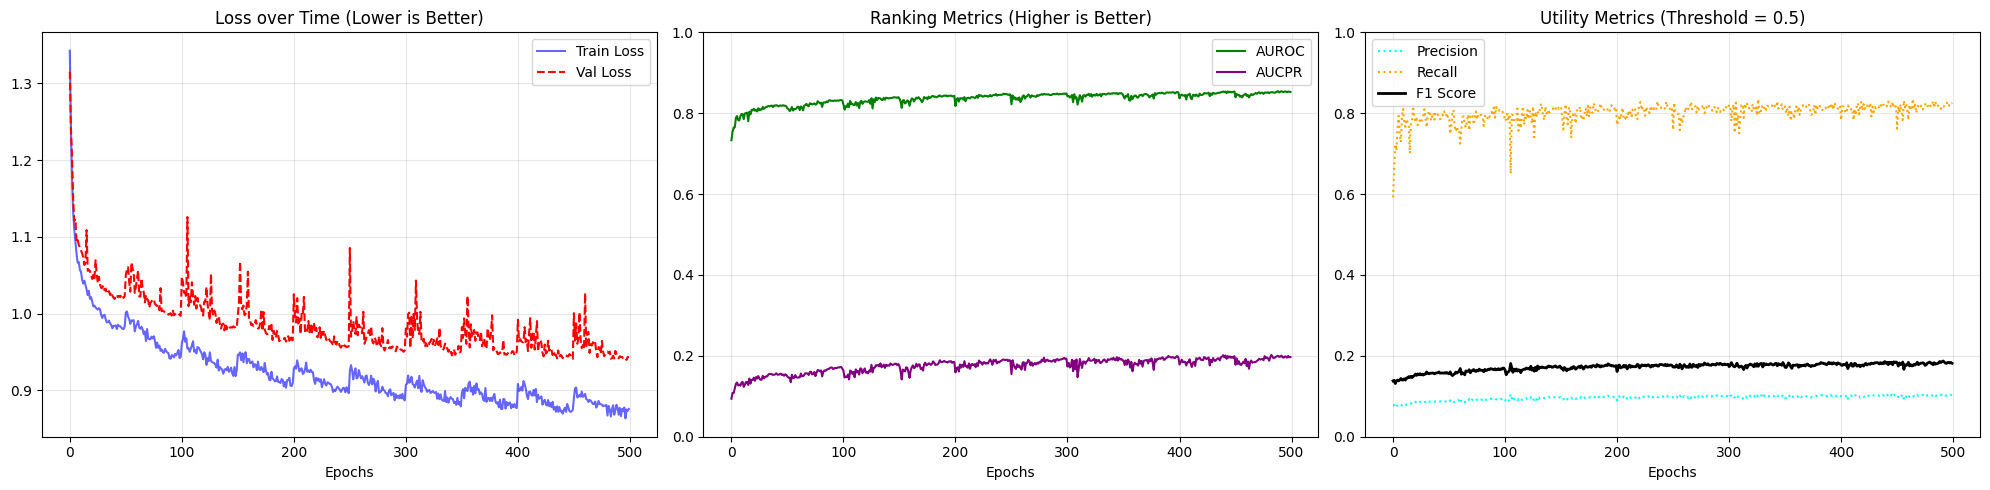

In [ ]:
import matplotlib.pyplot as plt

def plot_full_history(history):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

    ax1.plot(history['train_loss'], label='Train Loss', color='blue', alpha=0.6)
    ax1.plot(history['val_loss'], label='Val Loss', color='red', linestyle='--')
    ax1.set_title('Loss over Time (Lower is Better)')
    ax1.set_xlabel('Epochs')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax2.plot(history['val_auroc'], label='AUROC', color='green')
    ax2.plot(history['val_aucpr'], label='AUCPR', color='purple')
    ax2.set_title('Ranking Metrics (Higher is Better)')
    ax2.set_xlabel('Epochs')
    ax2.set_ylim([0, 1])
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    ax3.plot(history['val_precision'], label='Precision', color='cyan', linestyle=':')
    ax3.plot(history['val_recall'], label='Recall', color='orange', linestyle=':')
    ax3.plot(history['val_f1'], label='F1 Score', color='black', linewidth=2)
    ax3.set_title('Utility Metrics (Threshold = 0.5)')
    ax3.set_xlabel('Epochs')
    ax3.set_ylim([0, 1])
    ax3.grid(True, alpha=0.3)
    ax3.legend()

    plt.tight_layout()
    plt.show()

plot_full_history(history)

### Optimizing the threshold before testing (using the validation set for it)
- Using a single value for the optimal threshold

In [ ]:
# import numpy as np
# from sklearn.metrics import f1_score
# import torch

# def find_optimal_threshold(val_loader, model, device):
#     """
#     Sweeps through thresholds on the validation set to find the one
#     that maximizes the Micro-F1 score.
#     """
#     model.eval()
#     y_true_all = []
#     y_probs_all = []

#     # 1. Gather all probabilities from the Validation Set
#     with torch.no_grad():
#         for batch in val_loader:
#             batch = batch.to(device)
#             out = model(batch)
#             probs = torch.sigmoid(out) # Get probabilities between 0 and 1

#             y_true_all.append(batch.y.view(batch.num_graphs, -1).float())
#             y_probs_all.append(probs.cpu().numpy())

#     y_true = np.vstack(y_true_all)
#     y_probs = np.vstack(y_probs_all)

#     best_threshold = 0.5
#     best_f1 = 0.0

#     print("Sweeping thresholds...")

#     # 2. Test every threshold from 0.01 to 0.99 in increments of 0.01
#     thresholds_to_test = np.arange(0.01, 1.0, 0.01)

#     for thresh in thresholds_to_test:
#         # Convert probabilities to binary predictions using the current threshold
#         y_pred = (y_probs >= thresh).astype(int)

#         # Calculate Micro-F1
#         current_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)

#         # Keep track of the best one
#         if current_f1 > best_f1:
#             best_f1 = current_f1
#             best_threshold = thresh

#     print(f"Optimal Threshold Found: {best_threshold:.2f} (Val F1: {best_f1:.4f})")
#     return best_threshold

In [ ]:
# optimal_threshold = find_optimal_threshold(val_loader, model, device)

Sweeping thresholds...
Optimal Threshold Found: 0.75 (Val F1: 0.2641)


### Testing

In [ ]:
# def calculate_all_metrics(loader, model, device, criterion, threshold=0.5):
#     model.eval()
#     total_loss = 0
#     y_true_all = []
#     y_probs_all = []
#     y_pred_all = []

#     with torch.no_grad():
#         for batch in loader:
#             batch = batch.to(device)

#             # Forward pass
#             out = model(batch)

#             # Validation Loss
#             loss = criterion(out, batch.y.view(batch.num_graphs, -1).float())
#             total_loss += loss.item()

#             # Probabilities
#             probs = torch.sigmoid(out)

#             # Binary Predictions (for F1/Prec/Recall)
#             preds = (probs > threshold).float()

#             # Store
#             y_true_all.append(batch.y.view(batch.num_graphs, -1).float())
#             y_probs_all.append(probs.cpu().numpy())
#             y_pred_all.append(preds.cpu().numpy())

#     # Concatenate
#     y_true = np.vstack(y_true_all)
#     y_probs = np.vstack(y_probs_all)
#     y_pred = np.vstack(y_pred_all)

#     avg_loss = total_loss / len(loader)

#     # try:
#     auroc = roc_auc_score(y_true, y_probs, average='micro') # re-run
#     # except: auroc = 0.5

#     aucpr = average_precision_score(y_true, y_probs, average='micro')

#     precision = precision_score(y_true, y_pred, average='micro', zero_division=0)
#     recall = recall_score(y_true, y_pred, average='micro', zero_division=0)
#     f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)

#     return avg_loss, auroc, aucpr, precision, recall, f1

In [ ]:
# _, test_auroc, _, test_prec, test_rec, test_f1 = calculate_all_metrics(test_loader, model, device, criterion, optimal_threshold)

# print(f"{'AUROC':<10} | {'Precision':<10} | {'Recall':<10} | {'F1 Score':<10}")
# print("-" * 46)
# print(f"{test_auroc:<10.4f} | {test_prec:<10.4f} | {test_rec:<10.4f} | {test_f1:<10.4f}")
# print("-" * 46)

AUROC      | Precision  | Recall     | F1 Score  
----------------------------------------------
0.8561     | 0.1974     | 0.3825     | 0.2604    
----------------------------------------------


In [ ]:
# print("\nInterpretation:")
# print(f"- AUROC ({test_auroc:.2f}): Global ranking capability.")
# print(f"- Precision ({test_prec:.2f}): Reliability (How many predicted smells are real?).")
# print(f"- Recall ({test_rec:.2f}): Sensitivity (How many real smells did we find?).")

### Optimizing the threshold before testing (using the validation set for it)
  - Using one threshold adjusted for each label

In [ ]:
import numpy as np
from sklearn.metrics import f1_score
import torch

def find_per_label_thresholds(val_loader, model, device, num_classes=138):
    model.eval()
    y_true_all = []
    y_probs_all = []

    # 1. Gather all probabilities from the Validation Set
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch)
            probs = torch.sigmoid(out)

            y_true_all.append(batch.y.view(batch.num_graphs, -1).float())
            y_probs_all.append(probs.cpu().numpy())

    y_true = np.vstack(y_true_all)
    y_probs = np.vstack(y_probs_all)

    # Initialize an array to hold the 138 best thresholds (default to 0.5)
    best_thresholds = np.full(num_classes, 0.5)

    print(f"Sweeping thresholds for all {num_classes} labels individually...")

    # 2. Loop through each smell label (column)
    for class_idx in range(num_classes):
        # Isolate the true labels and probabilities for THIS specific smell
        y_true_class = y_true[:, class_idx]
        y_probs_class = y_probs[:, class_idx]

        # Safety check: If a smell doesn't exist in the validation set at all, skip it
        if np.sum(y_true_class) == 0:
            continue

        best_f1 = 0.0
        best_thresh = 0.5

        # Test thresholds for this specific smell
        for thresh in np.arange(0.01, 1.0, 0.01):
            y_pred_class = (y_probs_class >= thresh).astype(int)

            # Calculate the F1 score for this class only
            current_f1 = f1_score(y_true_class, y_pred_class, zero_division=0)

            if current_f1 > best_f1:
                best_f1 = current_f1
                best_thresh = thresh

        # Save the winning threshold for this smell
        best_thresholds[class_idx] = best_thresh

    print("Done! Found 138 optimal thresholds.")
    return best_thresholds

In [ ]:
optimal_thresholds = find_per_label_thresholds(val_loader, model, device)

Sweeping thresholds for all 138 labels individually...
Done! Found 138 optimal thresholds.


In [ ]:
thresholds_tensor = torch.tensor(optimal_thresholds, dtype=torch.float32).to(device)

In [ ]:
def calculate_all_metrics_thresh(loader, model, device, criterion, threshold=0.5):
    model.eval()
    total_loss = 0
    y_true_all = []
    y_probs_all = []
    y_pred_all = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            # Forward pass
            out = model(batch)

            # Validation Loss
            loss = criterion(out, batch.y.view(batch.num_graphs, -1).float())
            total_loss += loss.item()

            # Probabilities
            probs = torch.sigmoid(out)

            # Binary Predictions (for F1/Prec/Recall)
            preds = (probs > threshold).float()

            # Store
            y_true_all.append(batch.y.view(batch.num_graphs, -1).float())
            y_probs_all.append(probs.cpu().numpy())
            y_pred_all.append(preds.cpu().numpy())

    # Concatenate
    y_true = np.vstack(y_true_all)
    y_probs = np.vstack(y_probs_all)
    y_pred = np.vstack(y_pred_all)

    avg_loss = total_loss / len(loader)

    # try:
    auroc = roc_auc_score(y_true, y_probs, average='micro') # re-run
    # except: auroc = 0.5

    aucpr = average_precision_score(y_true, y_probs, average='micro')

    precision = precision_score(y_true, y_pred, average='micro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='micro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)

    return avg_loss, auroc, aucpr, precision, recall, f1

In [ ]:
_, test_auroc, _, test_prec, test_rec, test_f1 = calculate_all_metrics_thresh(test_loader, model, device, criterion, thresholds_tensor)

print(f"{'AUROC':<10} | {'Precision':<10} | {'Recall':<10} | {'F1 Score':<10}")
print("-" * 46)
print(f"{test_auroc:<10.4f} | {test_prec:<10.4f} | {test_rec:<10.4f} | {test_f1:<10.4f}")
print("-" * 46)

AUROC      | Precision  | Recall     | F1 Score  
----------------------------------------------
0.8578     | 0.2612     | 0.5291     | 0.3497    
----------------------------------------------


Testing for the new molecules:

In [ ]:
new_molecules

array(['CC(C)/C=C/C=C(\\C)/C=C', 'CC1=CCC2C(C1)C2(C)C',
       'CC(=CCCC(C)(C=C)O)C', 'CC1=C[C@H]2C[C@@H](C1)C2(C)C',
       'CC1=CC[C@H](CC1)C(=C)C', 'CC1=CC[C@@H](CC1)C(=C)C'], dtype=object)

In [ ]:
new_molecules_smells = []

for i in new_molecules:
  new_molecule_data = from_smiles(i, with_hydrogen=0)
  new_molecule_data.x = new_molecule_data.x.float()
  new_molecule_data = new_molecule_data.to(device)
  testing = model(new_molecule_data)
  probs = torch.sigmoid(testing)
  preds = (probs > thresholds_tensor).float()
  new_molecules_smells.append(preds)

  predicted_smells_indices = (preds.squeeze() == 1).nonzero(as_tuple=True)[0]
  predicted_smell_names = df.columns[2:][predicted_smells_indices].tolist()
  print("Predicted smells for ", i, ":\n\t", predicted_smell_names, sep = '')

Predicted smells for CC(C)/C=C/C=C(\C)/C=C:
	['citrus', 'earthy', 'fresh', 'grapefruit', 'green', 'herbal', 'lemon', 'metallic', 'spicy', 'terpenic', 'woody']
Predicted smells for CC1=CCC2C(C1)C2(C)C:
	['camphoreous', 'citrus', 'earthy', 'fresh', 'herbal', 'mint', 'pine', 'spicy', 'terpenic', 'woody']
Predicted smells for CC(=CCCC(C)(C=C)O)C:
	['citrus', 'cortex', 'earthy', 'floral', 'fresh', 'geranium', 'grapefruit', 'green', 'herbal', 'lavender', 'leafy', 'lemon', 'rose', 'sweet', 'terpenic', 'weedy', 'woody']
Predicted smells for CC1=C[C@H]2C[C@@H](C1)C2(C)C:
	['camphoreous', 'citrus', 'cooling', 'earthy', 'fresh', 'herbal', 'mint', 'pine', 'spicy', 'terpenic', 'woody']
Predicted smells for CC1=CC[C@H](CC1)C(=C)C:
	['citrus', 'earthy', 'fresh', 'grapefruit', 'green', 'herbal', 'lemon', 'pine', 'spicy', 'terpenic', 'weedy', 'woody']
Predicted smells for CC1=CC[C@@H](CC1)C(=C)C:
	['citrus', 'earthy', 'fresh', 'grapefruit', 'herbal', 'lemon', 'pine', 'spicy', 'terpenic', 'weedy', 'wood